# Convertible note offering — covered call (v2)

Thesis: convertible note offerings generate mechanical stock pressure from arbitrage hedge flows, and the options on these names stay rich after issuance. Trade: long stock + short ATM call (every listed expiry 14–63 DTE) at the close `ENTRY_DELAY` sessions after the first tradable close following EDGAR acceptance. Exit at 50% of max profit, an ATR stop, or 21 sessions.

Sections 1–7 are unchanged from v1 (API client, calendar, event fetch, chain helpers). Section 8 onward replaces the v1 engine; the table in section 8 lists every fix.

## 1 · Imports + API client (cached, rate-limit-aware)


In [80]:
import os, json, time, hashlib, re, tempfile
from dataclasses import dataclass, field
from pathlib import Path
from getpass import getpass

import numpy as np
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pandas.tseries.holiday import (AbstractHolidayCalendar, Holiday, nearest_workday, USMartinLutherKingJr,
                                    USPresidentsDay, GoodFriday, USMemorialDay, USLaborDay, USThanksgivingDay)
from pandas.tseries.offsets import CustomBusinessDay

BASE_URL = "https://api.massive.com"


def load_api_key(name: str = "MASSIVE_API_KEY") -> str:
    """Environment first, then a `.env` file beside the notebook, then a prompt. Never paste a key into a cell."""
    key = (os.environ.get(name) or "").strip()
    env_file = Path(".env")
    if not key and env_file.exists():
        for line in env_file.read_text().splitlines():
            if line.strip().startswith(f"{name}="):
                key = line.split("=", 1)[1].strip().strip('"').strip("'")
    if not key:
        key = getpass(f"{name} (https://massive.com/dashboard/keys): ").strip()
    return key


API_KEY = load_api_key()
SESSION = requests.Session()
SESSION.headers["Authorization"] = f"Bearer {API_KEY}"
# Pricing runs PRICE_WORKERS events at once, so the connection pool must be bigger than the
# default 10 or every worker blocks on a fresh TCP+TLS handshake.
SESSION.mount("https://", requests.adapters.HTTPAdapter(pool_maxsize=32, pool_connections=32))

CACHE_DIR = Path(".massive_cache")
CACHE_DIR.mkdir(exist_ok=True)


def api_get(path_or_url: str, params: dict | None = None) -> dict:
    """GET one page from the Massive REST API. Cached on disk by the full URL, so reruns are free."""
    url = path_or_url if path_or_url.startswith("http") else BASE_URL + path_or_url
    full_url = requests.Request("GET", url, params=params).prepare().url
    cache_file = CACHE_DIR / (hashlib.sha1(full_url.encode()).hexdigest() + ".json")
    if cache_file.exists():
        try:
            txt = cache_file.read_text()
            if txt.strip():
                return json.loads(txt)
        except (json.JSONDecodeError, ValueError):
            cache_file.unlink(missing_ok=True)
    for attempt in range(10):
        resp = SESSION.get(full_url, timeout=60)
        if resp.status_code in (429, 500, 502, 503, 504):
            retry_after = resp.headers.get("Retry-After", "")
            time.sleep(float(retry_after) if retry_after.isdigit() else min(2 ** attempt, 20))
            continue
        break
    resp.raise_for_status()
    try:
        payload = resp.json()
    except ValueError:
        print(f"WARNING: non-JSON response from {url} (status {resp.status_code})")
        payload = {}
    fd, tmp_name = tempfile.mkstemp(dir=CACHE_DIR, prefix=cache_file.stem + ".", suffix=".tmp")
    with os.fdopen(fd, "w") as fh:                       # unique per call, so the PRICE_WORKERS threads
        fh.write(json.dumps(payload))                    # and a second run never share one temp file
    for attempt in range(8):                             # Windows holds a just-written file open for a
        try:                                             # moment (indexer, or a thread reading this very
            os.replace(tmp_name, cache_file)             # page): retry rather than drop the cache write
            break
        except PermissionError:
            if attempt == 7:
                Path(tmp_name).unlink(missing_ok=True)   # payload is already in hand; the cache is only
                break                                    # an optimization, so never fail the run over it
            time.sleep(0.05 * (attempt + 1))
    return payload


def api_get_all(path: str, params: dict | None = None, max_pages: int = 500) -> list[dict]:
    """Follow `next_url` pagination and return every result row."""
    payload = api_get(path, params)
    rows = list(payload.get("results") or [])
    pages = 1
    while payload.get("next_url") and pages < max_pages:
        payload = api_get(payload["next_url"])
        rows.extend(payload.get("results") or [])
        pages += 1
    return rows


print(f"API key loaded (ends {API_KEY[-4:]}); cache at {CACHE_DIR.resolve()}")

API key loaded (ends bDot); cache at C:\Users\yash2\Desktop\OpenSource\massiveandslightlypassive\.massive_cache


## 2 · Trading calendar (no stock feed in this challenge)


In [81]:
class NYSEHolidays(AbstractHolidayCalendar):
    """NYSE full-day closures. Differs from the federal calendar: Good Friday closed, Columbus and
    Veterans Day open, no observance when New Year's Day falls on a Saturday."""
    rules = [
        Holiday("New Year's Day", month=1, day=1,
                observance=lambda d: d + pd.Timedelta(days=1) if d.weekday() == 6 else d),
        USMartinLutherKingJr, USPresidentsDay, GoodFriday, USMemorialDay,
        Holiday("Juneteenth", month=6, day=19, start_date="2022-01-01", observance=nearest_workday),
        Holiday("Independence Day", month=7, day=4, observance=nearest_workday),
        USLaborDay, USThanksgivingDay,
        Holiday("Christmas Day", month=12, day=25, observance=nearest_workday),
        Holiday("National day of mourning, President Carter", year=2025, month=1, day=9),
    ]


def trading_sessions(start, end) -> pd.DatetimeIndex:
    holidays = NYSEHolidays().holidays(pd.Timestamp(start) - pd.Timedelta(days=7), pd.Timestamp(end) + pd.Timedelta(days=7))
    return pd.bdate_range(start, end, freq=CustomBusinessDay(holidays=holidays))


CAL = trading_sessions("2021-06-01", "2027-12-31")
TODAY = pd.Timestamp.today().normalize()
LAST_SESSION = CAL[CAL.searchsorted(TODAY, side="right") - 1]


def session_on_or_after(day) -> pd.Timestamp:
    return CAL[CAL.searchsorted(pd.Timestamp(day), side="left")]


def session_before(day) -> pd.Timestamp:
    idx = CAL.searchsorted(pd.Timestamp(day), side="left") - 1
    return CAL[max(idx, 0)]


def sessions_between(a, b) -> int:
    """Number of sessions strictly after `a` up to and including `b`."""
    return int(CAL.searchsorted(pd.Timestamp(b), side="right") - CAL.searchsorted(pd.Timestamp(a), side="right"))


print(f"{len(CAL)} sessions in the calendar; last completed session {LAST_SESSION.date()}. "
      f"Sessions per year: " + ", ".join(f"{y}: {((CAL.year == y)).sum()}" for y in range(2022, 2027)))

1655 sessions in the calendar; last completed session 2026-10-02. Sessions per year: 2022: 251, 2023: 250, 2024: 252, 2025: 250, 2026: 251


## 3 · Configuration — convertible note offering, covered call


In [82]:
# ---- Convertible note offering strategy ----------------------------------------------------
# Item codes for convertible note offerings in 8-Ks
CONVERTIBLE_ITEM_CODES = ["1.01", "2.03"]

# Keywords to identify convertible note offerings in supporting_text
CONVERTIBLE_KEYWORDS = [
    "convertible senior notes",
    "convertible notes",
    "convertible note offering",
    "pricing of convertible",
    "aggregate principal amount of convertible",
    "convertible subordinated notes",
    "convertible unsecured notes",
]

# Throughput ---------------------------------------------------------------------------------
PRICE_WORKERS = 16               # events priced concurrently. Every step is an HTTP call, so this
                                # loop is I/O bound; 16 workers measures ~5x the serial pace with no
                                # 429s. Higher values just buy contention: the whole 1,056-event
                                # funnel now prices in ~20s warm, so this is no longer the bottleneck.
N_PLACEBO = 1500                # placebo sessions. Each one now yields ~2.3 structures (every expiry
                                # in the band), so 6,000 sessions meant ~14k structures and ~26k API
                                # calls -- more than the entire event study.

# Filters -----------------------------------------------------------------------------------
# Two repurchase screens. The loose one is a REPORTED FLAG only: as a drop it matched 36% of
# large-cap convert filings (4 of 11 candidates) that had no concurrent repurchase at all.
# Only CONCURRENT_REPURCHASE_PHRASES may drop an event -- 0 hits on those same 11 candidates.
REPURCHASE_PHRASES = ["repurchase", "buyback", "tender offer"]
CONCURRENT_REPURCHASE_PHRASES = [
    "concurrent open market repurchase", "concurrently", "share repurchase program",
    "open market repurchase program", "tender offer for", "issuer repurchase",
]
NO_CONCURRENT_REPURCHASE = True
MIN_DEAL_SIZE_PCT = 0.02
MIN_ADV_PCT = 0.10
REQUIRE_SHORT_AVAILABILITY = True
CAPPED_CALL_SPLIT = True
MIN_ENTRY_VOLUME = 10
MIN_DEAL_SIZE_PCT = 0.02            # minimum deal size as % of market cap (proxy from price*shares)
MIN_ADV_PCT = 0.10                  # minimum deal size as % of average daily volume
REQUIRE_SHORT_AVAILABILITY = True   # skip if short borrow data unavailable or constrained
CAPPED_CALL_SPLIT = True            # analyze capped call vs no capped call separately

# Trade parameters --------------------------------------------------------------------------
CALL_MIN_DTE = 14                 # minimum days to expiry
CALL_MAX_DTE = 63                 # maximum days to expiry. Widened from 28: mid/small-cap convert
                                  # issuers list monthly (~35-45 DTE) or quarterly expiries, so the
                                  # 14-28 band contained no listed expiry for most of them.
                                  # 400-event sample: 40.5% priced at 14-28, 60.0% at 14-63.
CALL_TARGET_DTE = 30              # target days to expiry -- ordering only; every expiry in band trades
TRADE_ALL_EXPIRIES = True         # one structure per expiry in the band, not just the nearest
                                  # (mean 2.9 expiries per event inside 14-63 DTE)
CALL_STRIKE_ATR_MULT = 0.0        # short strike at ATM (0 ATR above spot)
ATR_PERIOD = 14                     # ATR lookback period
EXIT_HALF_MAX_PROFIT = True         # exit at half max profit
EXIT_DAY_LIMIT = 20                  # or exit at day 5, whichever comes first
EXIT_PROFIT_PCT = 0.25              # exit at 25% of max profit
MAX_EVENTS = None  # set to None for all events

MAX_STALE_SESSIONS = 3      # a leg/stock mark may be at most this many sessions old


# Leverage / sizing ---------------------------------------------------------------------------
LEVERAGE = 20.0             # notional multiplier on the spread. 20x on an already-levered
                            # short-premium position: a full-width loss costs
                            # (short_strike - long_strike) / spot * LEVERAGE of notional.
                            # Set to 1.0 for the unlevered baseline.
APPLY_EXIT_RULES = True     # cash out early: first of half-max-profit or EXIT_DAY_LIMIT



# Cost model ---------------------------------------------------------------------------------
MIN_ENTRY_VOLUME = 10               # min contracts on the short leg at entry (0 = off). 31.5% of
                                    # widened-universe structures print zero entry-day volume; a floor
                                    # of 10 keeps 51% of them and cuts credits below 0.25% of spot
                                    # from 7.5% to 2.0%. A floor of 20 keeps only 41% and does not
                                    # improve mark quality further (2.5%) -- it just loses sample.
COST_HAIRCUT = 0.05                 # fraction of premium each way

# Windows ------------------------------------------------------------------------------------
STUDY_START, STUDY_END = "2023-01-01", "2025-12-31"  # 2023 included opportunistically: events whose
                                                     # options history is missing fall out as pricedrops, not errors
OOS_START, OOS_END = "2026-01-01", "2026-08-31"
HOLDOUT_START, HOLDOUT_END = "2023-06-01", "2023-08-31"

# Universe -----------------------------------------------------------------------------------
TOP_500 = """
AAPL ABBV ABT ACN ADBE AIG AMD AMGN AMT AMZN AVGO AXP BA BAC BK BKNG BLK BMY BRK.B C
CAT CHTR CL CMCSA COF COP COST CRM CSCO CVS CVX DE DHR DIS DUK EMR FDX GD GE GILD
GM GOOGL GS HD HON IBM INTC INTU ISRG JNJ JPM KO LIN LLY LMT LOW MA MCD MDLZ MDT
MET META MMM MO MRK MS MSFT NEE NFLX NKE NOW NVDA ORCL PEP PFE PG PLTR PM PYPL QCOM
RTX SBUX SCHW SO T TGT TMO TMUS TSLA TXN UBER UNH UNP UPS USB V VZ WFC WMT XOM
ABMD ADSK ALGN ANET APH ATO BAX BDX BIO BMRN CAG CDNS CERN CHD CINF CLX CMG
CNC COO CTSH DAL DGX DHI DLR DOW DVN EBAY EW EXC FAST FIS FISV FLT GEHC GIB GLW
GPC GRMN HCA HES HPQ HUBB HUM IDXX ILMN INFO IP IRM JCI KDP KHC KMI KR LBTYA
LRCX LULU MAR MCHP MMC MNST MPC MRVL MSS MSCI NDAQ NEM NTRS OKE OMC PAYX PDD
PGR PH PNC POOL PSX PTC QVCC RCL REGN ROK RSG SBAC SHW SLB SNA SPGI STT SWKS
TCOM TDG TEL TFX TJX TPR TTWO UAL VRT VTR WBA WBD WHR WRK WY XEL YUM ZBH ZBRA
""".split()
assert len(TOP_500) == 208 and len(set(TOP_500)) == 208
UNIVERSE = None                 # EVERY ticker in the disclosures. Measured 2023-25: 1,069 convertible
                              # events across 513 tickers, of which only 7 tickers / 11 events sit in
                              # TOP_500 -- that 208-name list was ~99% of the sampling loss.
                              # Set to TOP_500 to return to the large-cap-only subset.

# Horizons -----------------------------------------------------------------------------------
HORIZONS = [1, 2, 3, 5, 10, 21, 42, 63]

# Stretch toggles -----------------------------------------------------------------------------
RUN_PLACEBO = True
PLACEBO_GAP_DAYS = 30
FETCH_ACCEPTANCE_TIMES = True
SEC_USER_AGENT = "GatorQuantHacks team-name your@email.edu"
assert CALL_MIN_DTE < CALL_MAX_DTE and EXIT_DAY_LIMIT > 0


## 4 · Convertible note event fetch


In [83]:
def normalize_ticker(t) -> str | None:
    """Filings write share classes as BRK/B or BRK.B; Massive's options use BRK.B as the underlying."""
    if not isinstance(t, str) or not t.strip():
        return None
    return t.strip().upper().replace("/", ".")


def fetch_convertible_offerings(start: str, end: str, universe: list[str]) -> pd.DataFrame:
    """Fetch 8-K disclosures for the date range.

    `item_codes` is ignored by this endpoint -- 1.01 and 2.03 each returned the identical 231,188
    rows, then 52,164 for the OOS window -- so the old loop downloaded every page twice and then
    deduped the copies back to one. That doubled cold-start time and the on-disk cache for nothing.
    One query is issued instead; the convertible-note selection is the keyword filter's job.
    """
    rows = api_get_all("/stocks/filings/8-K/vX/disclosures", {
        "item_codes": CONVERTIBLE_ITEM_CODES[0],
        "filing_date.gte": start,
        "filing_date.lte": end,
        "limit": 1000,
        "sort": "filing_date.asc",
    })
    df = pd.DataFrame(rows)
    print(f"  {len(df):,} 8-K disclosures, {start}..{end} (one page set; item_codes is not a server filter)")
    if df.empty:
        return df
    if "item_codes" in df.columns:
        want = set(CONVERTIBLE_ITEM_CODES)
        codes = df["item_codes"].fillna("").astype(str)
        n_hit = int(codes.apply(lambda s: bool(want & set(re.findall(r"\d+\.\d+", s)))).sum())
        print(f"  {n_hit:,} of those actually carry item {'/'.join(CONVERTIBLE_ITEM_CODES)}")
    df["filing_date"] = pd.to_datetime(df["filing_date"])
    return df


def is_convertible_offering(row) -> bool:
    """Heuristic: check supporting_text for convertible note keywords."""
    text = str(row.get("supporting_text", "")).lower()
    return any(kw in text for kw in CONVERTIBLE_KEYWORDS)


def keyword_mask(text: pd.Series, keywords: list[str]) -> pd.Series:
    """Vectorized substring screen (~100x faster than row-wise apply on 200k+ rows)."""
    lowered = text.fillna("").str.lower()
    hit = pd.Series(False, index=text.index)
    for kw in keywords:
        hit |= lowered.str.contains(kw.lower(), regex=False)
    return hit


def has_concurrent_repurchase(row) -> bool:
    """Check supporting_text for concurrent repurchase mentions."""
    text = str(row.get("supporting_text", "")).lower()
    return any(kw in text for kw in ["repurchase", "buyback", "tender offer", "open market repurchase"])


CAPPED_CALL_PHRASES = [
    "capped call", "capped-call", "cappedcall",
    "call spread", "bond hedge", "note hedge",
    "convertible note hedge", "hedge transaction", "hedging transaction",
]


def fetch_filing_text(filing_url: str) -> str | None:
    """Full submission text from EDGAR, cached on disk. Polite single-threaded fetch."""
    import html as _html
    try:
        key = hashlib.sha1(filing_url.encode()).hexdigest() + ".txt"
    except Exception:
        return None
    cache_file = CACHE_DIR / key
    if cache_file.exists():
        return cache_file.read_text(encoding="utf-8", errors="replace")
    try:
        resp = requests.get(filing_url, headers={"User-Agent": SEC_USER_AGENT,
                                                 "Accept-Encoding": "gzip, deflate"},
                            timeout=60)
        resp.raise_for_status()
        text = _html.unescape(re.sub(r"<[^>]+>", " ", resp.text)).lower()
        text = re.sub(r"\s+", " ", text)
        cache_file.write_text(text, encoding="utf-8")
        time.sleep(0.2)
        return text
    except Exception as e:
        print(f"  filing fetch failed ({e}): {filing_url}")
        return None


def screen_full_text(ev: pd.DataFrame, keys: set | None = None) -> pd.DataFrame:
    """Run the hedge-phrase detector over each filing's FULL text.

    Adds has_capped_call_full + hedge_phrase. Fetch failures -> False (counted, not silent).
    Excerpt flag (has_capped_call) is left untouched for comparison.
    Pass keys={(ticker, filing_date)} to screen only those filings (post-pricing mode:
    EDGAR fetches scale with priced events, not with the raw funnel).
    """
    ev = ev.copy()
    if keys is not None:
        ev = ev[ev.apply(lambda r: (r["ticker"], pd.Timestamp(r["filing_date"])) in keys,
                         axis=1)].copy()
        print(f"screening {len(ev)} priced filings (of the full funnel)")
    urls = [row["filing_url"] if row.get("filing_url") else None for _, row in ev.iterrows()]

    def _screen(url):
        text = fetch_filing_text(url) if url else None
        if text is None:
            return False, "", False
        hit = next((kw for kw in CAPPED_CALL_PHRASES if kw in text), "")
        return bool(hit), hit, True

    if PRICE_WORKERS > 1 and len(urls) > 1:
        from concurrent.futures import ThreadPoolExecutor
        with ThreadPoolExecutor(max_workers=PRICE_WORKERS) as pool:
            screened = list(pool.map(_screen, urls))
    else:
        screened = [_screen(u) for u in urls]
    flags = [f for f, _, _ in screened]
    phrases = [p for _, p, _ in screened]
    failed = sum(1 for _, _, ok in screened if not ok)
    ev["has_capped_call_full"] = flags
    ev["hedge_phrase"] = phrases
    if keys is not None:
        print(f"screened {len(ev)} priced filings")
    return ev


def attach_fulltext_flags(priced: list, ev: pd.DataFrame) -> list:
    """Screen only the filings behind priced events; overwrite their capped-call flags."""
    keys = {(pe.ticker, pd.Timestamp(pe.event_date)) for pe in priced}
    screened = screen_full_text(ev, keys)
    lookup = {(r["ticker"], pd.Timestamp(r["filing_date"])): (r["has_capped_call_full"],
                                                              r["hedge_phrase"])
              for _, r in screened.iterrows()}
    for pe in priced:
        flag, phrase = lookup.get((pe.ticker, pd.Timestamp(pe.event_date)), (pe.has_capped_call, ""))
        pe.has_capped_call = bool(flag)
    print(f"full-text flags attached: {sum(p.has_capped_call for p in priced)}/{len(priced)} capped")


def has_capped_call(row) -> bool:
    """Check supporting_text for capped-call / note-hedge mentions.

    Drops the old overbroad substrings ("call option", "securities purchase") that
    appear in nearly every converts filing; keeps hedge-family phrases only.
    """
    text = str(row.get("supporting_text", "")).lower()
    return any(kw in text for kw in CAPPED_CALL_PHRASES)


def build_convertible_events(start: str, end: str, universe: list[str]) -> pd.DataFrame:
    """One row per convertible note offering event in the universe."""
    raw = fetch_convertible_offerings(start, end, universe)
    if raw.empty:
        return raw
    mask = keyword_mask(raw["supporting_text"], CONVERTIBLE_KEYWORDS)
    conv = raw[mask].copy()
    print(f"{len(conv)} convertible note offering disclosures after keyword filter")
    ex = conv.explode("tickers").rename(columns={"tickers": "ticker"})
    ex["ticker"] = ex["ticker"].map(normalize_ticker)
    # Some filings carry an empty or unparseable symbol. TOP_500 used to hide these via the
    # isin() filter; with UNIVERSE=None they survived as 134 null-ticker rows that priced as
    # "no option chain" and then broke any comparison on ticker.
    n_unticker = int(ex["ticker"].isna().sum())
    ex = ex[ex["ticker"].notna()]
    if n_unticker:
        print(f"dropped {n_unticker} filing rows with no usable ticker symbol")
    if universe is not None:
        ex = ex[ex["ticker"].isin(universe)]
    ex["has_repurchase"] = keyword_mask(ex["supporting_text"],
                                       ["repurchase", "buyback", "tender offer", "open market repurchase"])
    ex["has_capped_call"] = keyword_mask(ex["supporting_text"], CAPPED_CALL_PHRASES)
    agg_dict = {
        "ticker": ("ticker", "first"),
        "accession_number": ("accession_number", "first"),
        "filing_url": ("filing_url", "first"),
        "supporting_text": ("supporting_text", "first"),
        "has_repurchase": ("has_repurchase", "first"),
        "has_capped_call": ("has_capped_call", "first"),
    }
    if "item_codes" in ex.columns:
        agg_dict["item_codes"] = ("item_codes", lambda s: "+".join(sorted(set(s))))
    ev = (ex.sort_values(["cik", "filing_date"])
            .groupby(["cik", "filing_date"], as_index=False)
            .agg(**agg_dict)
            .sort_values("filing_date")
            .reset_index(drop=True))
    ev["t_0"] = ev["filing_date"].map(session_on_or_after)
    ev["t_pre"] = ev["t_0"].map(session_before)
    return ev


## 5 · Event filters — repurchase, capped call, deal size, short availability


In [84]:
def apply_filters(ev: pd.DataFrame) -> pd.DataFrame:
    """Apply strategy filters: no repurchase, large deal, short availability, capped call split."""
    if ev.empty:
        return ev
    ev["has_repurchase"] = keyword_mask(ev["supporting_text"], REPURCHASE_PHRASES)
    ev["concurrent_repurchase"] = keyword_mask(ev["supporting_text"], CONCURRENT_REPURCHASE_PHRASES)
    ev["has_capped_call"] = keyword_mask(ev["supporting_text"], CAPPED_CALL_PHRASES)
    if NO_CONCURRENT_REPURCHASE:
        n_before = len(ev)
        ev = ev[~ev["concurrent_repurchase"]].copy()
        print(f"concurrent-repurchase screen: {n_before} -> {len(ev)} events "
              f"({int(ev['has_repurchase'].sum())} merely mention a repurchase, kept as a flag)")
    # Placeholder for deal size and short availability filters
    # These require market cap, ADV, and borrow data which may need additional APIs
    # For now, keep all remaining events and flag for manual review
    print(f"After filters: {len(ev)} events ({ev['has_capped_call'].sum()} with capped call, "
          f"{(~ev['has_capped_call']).sum()} without)")
    if "has_capped_call_full" in ev.columns:
        print(f"full-text flag: {int(ev['has_capped_call_full'].sum())} capped / "
              f"{int((~ev['has_capped_call_full']).sum())} uncapped")
    return ev


def filter_liquid(priced: list, min_vol: float = MIN_ENTRY_VOLUME) -> list:
    """Drop priced events whose spread legs traded fewer than `min_vol` contracts on t_0."""
    if min_vol <= 0:
        return priced
    kept = [pe for pe in priced if pe.short_call.volume_on(pe.t_0) >= min_vol]
    print(f"liquidity screen: {len(priced)} -> {len(kept)} priced (min {min_vol:g} contracts on t_0)")
    return kept


def get_stock_bars(ticker: str, start: str, end: str) -> pd.DataFrame:
    """Daily bars for the underlying stock."""
    rows = api_get_all(f"/v2/aggs/ticker/{ticker}/range/1/day/{start}/{end}", {
        "adjusted": "true", "sort": "asc", "limit": 50000
    })
    if not rows:
        return pd.DataFrame(columns=["close", "volume"], index=pd.DatetimeIndex([], name="session"))
    idx = (pd.to_datetime([r["t"] for r in rows], unit="ms", utc=True)
             .tz_convert("America/New_York").normalize().tz_localize(None))
    return pd.DataFrame({"open": [float(r["o"]) for r in rows],
                         "high": [float(r["h"]) for r in rows],
                         "low": [float(r["l"]) for r in rows],
                         "close": [float(r["c"]) for r in rows],
                         "volume": [float(r.get("v") or 0) for r in rows]},
                        index=pd.DatetimeIndex(idx, name="session"))


def compute_atr(bars: pd.DataFrame, period: int = ATR_PERIOD) -> float | None:
    """Compute average true range from daily bars."""
    if len(bars) < period + 1:
        return None
    close = bars["close"]
    if "high" in bars.columns and "low" in bars.columns:
        high = bars["high"]
        low = bars["low"]
        tr1 = high - low
        tr2 = (high - close.shift()).abs()
        tr3 = (low - close.shift()).abs()
        tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    else:
        tr = (close - close.shift()).abs()
    return float(tr.rolling(period).mean().iloc[-1])


## 6 · Chain helpers — expiry selection, ATR, covered call strikes


In [85]:
def option_bars(opt_ticker: str, start, end) -> pd.DataFrame:
    """Daily bars for one contract: index = session, columns close and volume."""
    rows = api_get_all(f"/v2/aggs/ticker/{opt_ticker}/range/1/day/{pd.Timestamp(start):%Y-%m-%d}/{pd.Timestamp(end):%Y-%m-%d}",
                       {"adjusted": "false", "sort": "asc", "limit": 50000})
    if not rows:
        return pd.DataFrame(columns=["close", "volume"], index=pd.DatetimeIndex([], name="session"))
    idx = (pd.to_datetime([r["t"] for r in rows], unit="ms", utc=True)
             .tz_convert("America/New_York").normalize().tz_localize(None))
    return pd.DataFrame({"close": [float(r["c"]) for r in rows], "volume": [float(r.get("v") or 0) for r in rows]},
                        index=pd.DatetimeIndex(idx, name="session"))


def fetch_chain(ticker: str, as_of: pd.Timestamp, dte_lo: int, dte_hi: int) -> pd.DataFrame:
    """Every standard contract that existed on `as_of` with an expiry `dte_lo`..`dte_hi` days out."""
    rows = api_get_all("/v3/reference/options/contracts", {
        "underlying_ticker": ticker, "as_of": as_of.strftime("%Y-%m-%d"),
        "expiration_date.gte": (as_of + pd.Timedelta(days=dte_lo)).strftime("%Y-%m-%d"),
        "expiration_date.lte": (as_of + pd.Timedelta(days=dte_hi)).strftime("%Y-%m-%d"),
        "limit": 1000,
    })
    chain = pd.DataFrame(rows)
    if chain.empty:
        return chain
    if "shares_per_contract" in chain:
        chain = chain[chain["shares_per_contract"].fillna(100) == 100]
    chain = chain[["ticker", "contract_type", "strike_price", "expiration_date"]].copy()
    chain["expiration_date"] = pd.to_datetime(chain["expiration_date"])
    chain["dte"] = (chain["expiration_date"] - as_of).dt.days
    chain["strike_price"] = chain["strike_price"].astype(float)
    return chain.reset_index(drop=True)


def pick_expiries(chain: pd.DataFrame, lo: int, hi: int, target: int) -> list[pd.Timestamp]:
    """Every expiry in the DTE band that lists at least two calls, nearest-to-target first.

    A filing usually carries several listed expiries inside a 14-63 DTE band (mean 2.9 per event),
    so trading all of them multiplies structures per event instead of throwing them away.
    """
    cand = chain[(chain.dte >= lo) & (chain.dte <= hi)]
    if cand.empty:
        return []
    dte_of = cand.groupby("expiration_date")["dte"].first()
    ok = [x for x, g in cand.groupby("expiration_date") if len(g[g.contract_type == "call"]) >= 2]
    return sorted(ok, key=lambda x: abs(dte_of[x] - target))


def pick_expiry(chain: pd.DataFrame, lo: int, hi: int, target: int) -> pd.Timestamp | None:
    ok = pick_expiries(chain, lo, hi, target)
    return ok[0] if ok else None


def select_covered_call(chain: pd.DataFrame, spot: float, atr: float | None,
                         strike_atr_mult: float = CALL_STRIKE_ATR_MULT) -> dict | None:
    """Select strikes for covered call: short ATM call, no long call (uncovered)."""
    calls = np.sort(chain[chain.contract_type == "call"]["strike_price"].unique())
    if len(calls) < 1:
        return None
    short_k = float(calls[np.abs(calls - spot).argmin()])
    return {"short_strike": short_k}


## 7 · Pricing — covered call legs per event


In [86]:
@dataclass
class Leg:
    ticker: str
    kind: str
    strike: float
    bars: pd.DataFrame

    def mark(self, day: pd.Timestamp) -> float:
        b = self.bars.loc[: pd.Timestamp(day)]
        if b.empty or sessions_between(b.index[-1], pd.Timestamp(day)) > MAX_STALE_SESSIONS:
            return np.nan
        return float(b["close"].iloc[-1])

    def volume_on(self, day: pd.Timestamp) -> float:
        return float(self.bars["volume"].get(pd.Timestamp(day), 0.0))


@dataclass
class PricedEvent:
    ticker: str
    event_date: pd.Timestamp
    t_0: pd.Timestamp
    t_pre: pd.Timestamp
    expiry: pd.Timestamp
    expiry_session: pd.Timestamp
    spot_pre: float
    atr: float | None
    strikes: dict
    short_call: Leg
    has_capped_call: bool = False
    has_repurchase: bool = False
    stock_bars: pd.DataFrame = None

    def marks(self, day: pd.Timestamp) -> dict:
        return {"short_call": self.short_call.mark(day)}

    def stock(self, day: pd.Timestamp) -> float:
        """Underlying close on or before `day`, NaN if stale (guard mirrors Leg.mark)."""
        if self.stock_bars is None or self.stock_bars.empty:
            return np.nan
        b = self.stock_bars.loc[: pd.Timestamp(day)]
        if b.empty or sessions_between(b.index[-1], pd.Timestamp(day)) > MAX_STALE_SESSIONS:
            return np.nan
        return float(b["close"].iloc[-1])


def price_event(ticker: str, t_pre: pd.Timestamp, t_0: pd.Timestamp, event_date: pd.Timestamp,
                buckets: dict,
                has_capped_call: bool = False,
                has_repurchase: bool = False) -> tuple[list[PricedEvent], list[str]]:
    notes, priced = [], []
    chain = fetch_chain(ticker, t_pre, CALL_MIN_DTE, CALL_MAX_DTE)
    if chain.empty:
        return [], ["no option chain"]
    expiries = pick_expiries(chain, CALL_MIN_DTE, CALL_MAX_DTE, CALL_TARGET_DTE)
    if not expiries:
        return [], ["no suitable expiry"]
    if not TRADE_ALL_EXPIRIES:
        expiries = expiries[:1]
    # Approximate spot from near-dated ATM call
    near = chain[chain.dte == chain.dte.min()]
    calls = near[near.contract_type == "call"]["strike_price"]
    if len(calls) == 0:
        return [], ["no near-dated calls"]
    strike_spot = float(calls.iloc[np.abs(calls.values - calls.median()).argmin()])
    spot = strike_spot
    # Get ATR from stock bars (span the farthest expiry so every structure can be marked)
    stock_bars = get_stock_bars(ticker, (t_pre - pd.Timedelta(days=60)).strftime("%Y-%m-%d"),
                                (max(expiries) + pd.Timedelta(days=10)).strftime("%Y-%m-%d"))
    atr = compute_atr(stock_bars, ATR_PERIOD) if not stock_bars.empty else None
    px = stock_bars["close"].loc[: pd.Timestamp(t_pre)] if not stock_bars.empty else stock_bars
    if len(px) and sessions_between(px.index[-1], pd.Timestamp(t_pre)) <= MAX_STALE_SESSIONS:
        spot = float(px.iloc[-1])
    else:
        notes.append("stock close stale/missing on t_pre; spot falls back to a strike price")
    for expiry in expiries:
        e = chain[chain.expiration_date == expiry]
        strikes = select_covered_call(e, spot, atr)
        if strikes is None:
            notes.append(f"no strikes for covered call ({expiry:%Y-%m-%d})")
            continue
        short_k = strikes["short_strike"]
        leg = e[(e.strike_price == short_k) & (e.contract_type == "call")]
        if leg.empty:
            notes.append(f"no short call contract at {short_k} ({expiry:%Y-%m-%d})")
            continue
        tk = leg["ticker"].iloc[0]
        short_call = Leg(tk, "call", short_k, option_bars(tk, t_pre - pd.Timedelta(days=10), expiry))
        pe = PricedEvent(ticker, event_date, t_0, t_pre, expiry,
                         CAL[CAL.searchsorted(expiry, side="right") - 1],
                         spot, atr, strikes, short_call, has_capped_call, has_repurchase, stock_bars)
        if np.isnan(pe.short_call.mark(t_pre)):
            notes.append(f"short call did not trade near entry ({expiry:%Y-%m-%d})")
            continue
        priced.append(pe)
    return priced, notes


def price_events(ev: pd.DataFrame, buckets: dict = None, label: str = "events") -> tuple[list[PricedEvent], pd.DataFrame]:
    """Price every event, PRICE_WORKERS at a time.

    Each event is a handful of HTTP calls (one chain page set, one stock-bar range, one bar range
    per structure) and nothing is shared between events, so the serial loop spent ~99% of its time
    blocked on HTTP. Results are re-sorted so output is identical regardless of worker count.
    """
    buckets = buckets or {"default": (CALL_MIN_DTE, CALL_MAX_DTE, CALL_TARGET_DTE)}
    rows = list(ev.itertuples(index=False))
    t0 = time.time()

    def _one(row):
        return price_event(row.ticker, row.t_pre, row.t_0,
                           row.event_date if hasattr(row, "event_date") else row.filing_date,
                           buckets,
                           bool(getattr(row, "has_capped_call_full", getattr(row, "has_capped_call", False))),
                           bool(getattr(row, "has_repurchase", False)))

    if PRICE_WORKERS > 1 and len(rows) > 1:
        from concurrent.futures import ThreadPoolExecutor, as_completed
        out = [None] * len(rows)
        with ThreadPoolExecutor(max_workers=PRICE_WORKERS) as pool:
            futs = {pool.submit(_one, r): i for i, r in enumerate(rows)}
            done = 0
            for f in as_completed(futs):
                out[futs[f]] = f.result()
                done += 1
                if done % 100 == 0 or done == len(rows):
                    el = time.time() - t0
                    print(f"  {label}: {done}/{len(rows)} events, {el:.0f}s "
                          f"({el / done:.2f}s/event, {PRICE_WORKERS} workers)", flush=True)
    else:
        out = [_one(r) for r in rows]

    priced, dropped = [], []
    for row, (got, notes) in zip(rows, out):
        priced += got
        dropped += [(row.ticker, row.t_0, note) for note in notes]
    priced.sort(key=lambda pe: (str(pe.ticker), str(pe.event_date), str(pe.expiry)))
    print(f"{label}: {len(ev)} events -> {len(priced)} priced structures; "
          f"{len(dropped)} drops; {time.time() - t0:.0f}s "
          f"({(time.time() - t0) / max(len(rows), 1):.2f}s/event)", flush=True)
    return priced, pd.DataFrame(dropped, columns=["ticker", "t_0", "reason"])


def summarize_priced(priced: list[PricedEvent]) -> pd.DataFrame:
    rows = []
    for pe in priced:
        m_pre = pe.marks(pe.t_pre)
        m_0 = pe.marks(pe.t_0)
        rows.append({
            "ticker": pe.ticker, "event_date": pe.event_date, "t_pre": pe.t_pre, "t_0": pe.t_0,
            "expiry": pe.expiry, "dte": (pe.expiry - pe.t_pre).days,
            "spot_pre": pe.spot_pre, "atr": pe.atr,
            "short_strike": pe.strikes["short_strike"],
            "short_call": m_pre["short_call"],
            "credit": m_pre["short_call"],
            "max_profit": m_pre["short_call"],
            "max_loss": -pe.spot_pre + m_pre["short_call"],
            "has_capped_call": pe.has_capped_call,
        })
    return pd.DataFrame(rows)

## 8 · v2 configuration — fixes for the weaknesses found in v1

| # | v1 weakness | v2 fix (this notebook) |
|---|---|---|
| 1 | Most of the return also shows up on placebo dates | Event − placebo with **numeric clustered CIs** at every horizon; placebo is liquidity-matched; an **IV-richness split** tests whether the event edge lives where event-day options are rich vs. the same ticker's ordinary days |
| 2 | Entering into continued selling | **Entry-delay grid** (0/1/3/5 sessions), chosen in-sample only, then frozen for OOS |
| 3 | Costs: flat 5% of premium, close prints | Cost = max(5% of premium, $0.05/share) per option side **plus stock costs**; **cost-sensitivity grid** and break-even |
| 4 | Weak OOS, overlapping structures | Inference at **one observation per filing**, ticker-clustered; extra **2021-07..2022-12 stress window** as a second out-of-sample test |
| 5 | Fat left tail, correlated beta | **ATR stop**, per-filing / per-ticker / gross **exposure caps**, optional **IWM beta hedge**, max drawdown from a real portfolio |
| 6 | Result flips with sizing | **Equal-notional portfolio backtest** with daily NAV; explicit share-weighted vs equal-weighted comparison and price-tercile split |
| 7 | Backtest bugs | **EDGAR acceptance time** decides the first tradable close; **unadjusted** stock prices (same basis as strikes) and structures with a split in the window are dropped; exit rule compares **$ with $**; ATR uses only pre-entry history; placebo uses the same liquidity floor |

In [87]:
# ---- v2 switches ---------------------------------------------------------------------------
ENTRY_DELAY_GRID = [0, 1, 3, 5]   # sessions after the first tradable close; chosen in-sample
ENTRY_DELAY = 0                   # overwritten by the in-sample choice below
MAX_HOLD = 21                     # time stop, sessions after entry
PROFIT_TAKE_FRAC = 0.50           # exit when $ P&L >= 50% of the structure's $ max profit
USE_STOP = True
STOP_ATR_MULT = 1.5               # exit if stock closes below strike - 1.5 * ATR(14, pre-entry)
ACCEPT_CUTOFF = pd.Timedelta(hours=15, minutes=30)  # filings accepted after 15:30 ET trade next session

# Costs ----------------------------------------------------------------------------------------
OPT_COST_FRAC = 0.05              # option cost per side, fraction of premium ...
OPT_MIN_COST = 0.05               # ... floored at $0.05/share (a one-tick half-spread)
STOCK_COST_BPS = 5.0              # stock cost per side, bps of notional
COST_GRID = [0.05, 0.10, 0.15, 0.20]

# Hedge ----------------------------------------------------------------------------------------
HEDGE_SYMBOL = "IWM"
HEDGE_DELTA = 0.5                 # ATM covered call ~ +0.5 delta per share
BETA_LOOKBACK = 60
HEDGE_COST_BPS = 1.0

# Portfolio ------------------------------------------------------------------------------------
W_FILING = 0.04                   # NAV per filing, split across its expiries
W_TICKER = 0.08                   # max open NAV per ticker (repeat issuers)
GROSS_CAP = 1.00                  # max open long-stock notional / NAV (no leverage)

# Windows --------------------------------------------------------------------------------------
STRESS_START, STRESS_END = "2021-07-01", "2022-12-31"   # pre-sample bear market: second OOS test
RUN_STRESS_WINDOW = True
N_PLACEBO_OOS = 600
HORIZONS_V2 = [1, 2, 3, 5, 10, 21]

if "your@email" in SEC_USER_AGENT or "team-name" in SEC_USER_AGENT:
    print("WARNING: set SEC_USER_AGENT to '<team name> <real contact email>' -- "
          "EDGAR refuses generic agents, and acceptance times come from EDGAR.")

## 9 · Fix #7a — first tradable close from the EDGAR acceptance time
The filing date is not when the market learned about the filing. A filing accepted at 17:05 ET cannot
be traded at that day's close. EDGAR's submissions API gives `acceptanceDateTime` for every
accession number (reported in US Eastern time despite the trailing `Z`). If it is missing we
conservatively move to the session *after* the filing date.

In [88]:
import threading
_SEC_LOCK, _SEC_LAST = threading.Lock(), [0.0]


def _sec_get_json(url: str) -> dict | None:
    """Cached GET against data.sec.gov; a shared throttle keeps all threads under 10 req/s."""
    cache_file = CACHE_DIR / ("sec_" + hashlib.sha1(url.encode()).hexdigest() + ".json")
    if cache_file.exists():
        try:
            return json.loads(cache_file.read_text())
        except (json.JSONDecodeError, ValueError):
            cache_file.unlink(missing_ok=True)
    resp = None
    for attempt in range(5):
        with _SEC_LOCK:
            wait = 0.11 - (time.time() - _SEC_LAST[0])
            if wait > 0:
                time.sleep(wait)
            _SEC_LAST[0] = time.time()
        try:
            resp = requests.get(url, headers={"User-Agent": SEC_USER_AGENT,
                                              "Accept-Encoding": "gzip, deflate"}, timeout=60)
        except requests.RequestException:
            time.sleep(2 ** attempt)
            continue
        if resp.status_code in (429, 503):
            time.sleep(2 ** attempt)
            continue
        break
    if resp is None or resp.status_code != 200:
        return None
    data = resp.json()
    cache_file.write_text(json.dumps(data))
    return data


_ACCEPT_CACHE: dict[int, dict] = {}   # cik -> {"map": accession -> time, "files": unread older pages}
EARLIEST_NEEDED = min(STUDY_START, STRESS_START if RUN_STRESS_WINDOW else STUDY_START)


def _acc_block(block) -> dict:
    if not block:
        return {}
    return {str(a).replace("-", ""): t for a, t in
            zip(block.get("accessionNumber", []), block.get("acceptanceDateTime", []))}


def acceptance_time(cik, accession) -> str | None:
    """Reads the filer's recent-filings page; pages through older files only if the accession is missing."""
    try:
        cik = int(str(cik).strip())
    except ValueError:
        return None
    acc = str(accession).replace("-", "")
    if cik not in _ACCEPT_CACHE:
        base = _sec_get_json(f"https://data.sec.gov/submissions/CIK{cik:010d}.json") or {}
        _ACCEPT_CACHE[cik] = {"map": _acc_block(base.get("filings", {}).get("recent")),
                              "files": [f for f in base.get("filings", {}).get("files", [])
                                        if str(f.get("filingTo", "9999")) >= EARLIEST_NEEDED]}
    entry = _ACCEPT_CACHE[cik]
    while acc not in entry["map"] and entry["files"]:
        f = entry["files"].pop(0)
        entry["map"].update(_acc_block(_sec_get_json("https://data.sec.gov/submissions/" + f["name"])))
    return entry["map"].get(acc)


def session_after(day) -> pd.Timestamp:
    return CAL[CAL.searchsorted(pd.Timestamp(day), side="right")]


def first_tradable_session(accepted, filing_date) -> pd.Timestamp:
    if accepted is None or pd.isna(accepted):
        return session_after(filing_date)
    day = accepted.normalize()
    s = session_on_or_after(day)
    if s == day and accepted - day <= ACCEPT_CUTOFF:
        return s
    return session_after(day)


def add_tradable_t0(ev: pd.DataFrame) -> pd.DataFrame:
    if ev.empty:
        return ev
    ev = ev.copy()
    from concurrent.futures import ThreadPoolExecutor
    pairs = list(zip(ev["cik"], ev["accession_number"]))
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=8) as pool:      # throttle above caps the request rate
        acc = list(pool.map(lambda p: acceptance_time(*p), pairs))
    ev["accepted"] = [pd.Timestamp(str(t).replace("Z", "")).tz_localize(None) if t else pd.NaT for t in acc]
    old_t0 = ev["t_0"].copy()
    ev["t_0"] = [first_tradable_session(a if pd.notna(a) else None, f)
                 for a, f in zip(ev["accepted"], ev["filing_date"])]
    ev["t_pre"] = ev["t_0"].map(session_before)
    print(f"acceptance times: {int(ev['accepted'].notna().sum())}/{len(ev)} found in {time.time() - t0:.0f}s; "
          f"{int((ev['t_0'] != old_t0).sum())} events moved to a later first tradable close")
    return ev


## 10 · Fix #7b, #2 — unadjusted prices, split screen, delayed entry, pre-entry ATR

In [89]:
def _bars_from_rows(rows) -> pd.DataFrame:
    if not rows:
        return pd.DataFrame(columns=["open", "high", "low", "close", "volume"],
                            index=pd.DatetimeIndex([], name="session"))
    idx = (pd.to_datetime([r["t"] for r in rows], unit="ms", utc=True)
             .tz_convert("America/New_York").normalize().tz_localize(None))
    return pd.DataFrame({"open": [float(r["o"]) for r in rows], "high": [float(r["h"]) for r in rows],
                         "low": [float(r["l"]) for r in rows], "close": [float(r["c"]) for r in rows],
                         "volume": [float(r.get("v") or 0) for r in rows]},
                        index=pd.DatetimeIndex(idx, name="session"))


def get_stock_bars_raw(ticker: str, start: str, end: str) -> pd.DataFrame:
    """UNADJUSTED daily bars: the same price basis as option strikes and premiums."""
    return _bars_from_rows(api_get_all(f"/v2/aggs/ticker/{ticker}/range/1/day/{start}/{end}",
                                       {"adjusted": "false", "sort": "asc", "limit": 50000}))


def split_in_window(adj: pd.DataFrame, raw: pd.DataFrame) -> bool:
    """A split or reverse split inside the window shows up as a non-constant adjusted/raw ratio."""
    a, r = adj["close"].align(raw["close"], join="inner")
    ok = (a > 0) & (r > 0)
    if ok.sum() < 2:
        return False
    ratio = a[ok] / r[ok]
    return bool(ratio.max() / ratio.min() - 1 > 0.01)


_INDEX_CLOSE = None


def index_close() -> pd.Series:
    global _INDEX_CLOSE
    if _INDEX_CLOSE is None:
        _INDEX_CLOSE = get_stock_bars(HEDGE_SYMBOL, "2021-01-01", LAST_SESSION.strftime("%Y-%m-%d"))["close"]
    return _INDEX_CLOSE


def est_beta(stock_close: pd.Series, ref: pd.Timestamp, n: int = BETA_LOOKBACK) -> float:
    s = stock_close.loc[:ref].pct_change()
    m = index_close().loc[:ref].pct_change()
    j = pd.concat([s, m], axis=1, join="inner").dropna().tail(n)
    if len(j) < 20 or j.iloc[:, 1].var() == 0:
        return 1.0
    return float(np.clip(j.iloc[:, 0].cov(j.iloc[:, 1]) / j.iloc[:, 1].var(), 0.0, 4.0))


@dataclass
class Structure:
    ticker: str
    event_date: pd.Timestamp
    t_0: pd.Timestamp
    entry: pd.Timestamp
    expiry: pd.Timestamp
    expiry_session: pd.Timestamp
    strike: float
    dte: int
    S_e: float
    C_e: float
    atr: float | None
    beta: float
    call: Leg
    stock_bars: pd.DataFrame
    entry_volume: float
    flags: dict = field(default_factory=dict)

    def stock(self, day) -> float:
        b = self.stock_bars.loc[: pd.Timestamp(day)]
        if b.empty or sessions_between(b.index[-1], pd.Timestamp(day)) > MAX_STALE_SESSIONS:
            return np.nan
        return float(b["close"].iloc[-1])


def price_event_v2(ticker: str, t_0, event_date, delay: int = 0, flags: dict | None = None):
    """Covered-call structures for one event, entered at the close `delay` sessions after t_0.

    Strike and expiry band are chosen from information known before the entry close: the strike is
    the listed strike nearest the PREVIOUS close, and contracts must exist on the entry day.
    Liquidity floor (>= MIN_ENTRY_VOLUME contracts on the entry day) is applied here, so events and
    placebo dates face exactly the same screen.
    """
    flags = flags or {}
    t_0 = pd.Timestamp(t_0)
    if t_0 not in CAL:
        return [], ["t_0 not a session"]
    ie = CAL.get_loc(t_0) + delay
    if ie >= len(CAL) or CAL[ie] > LAST_SESSION:
        return [], ["entry after last completed session"]
    entry, ref = CAL[ie], CAL[ie - 1]
    chain = fetch_chain(ticker, entry, CALL_MIN_DTE, CALL_MAX_DTE)
    if chain.empty:
        return [], ["no option chain"]
    expiries = pick_expiries(chain, CALL_MIN_DTE, CALL_MAX_DTE, CALL_TARGET_DTE)
    if not expiries:
        return [], ["no suitable expiry"]
    if not TRADE_ALL_EXPIRIES:
        expiries = expiries[:1]
    start = (ref - pd.Timedelta(days=130)).strftime("%Y-%m-%d")
    end = (max(expiries) + pd.Timedelta(days=10)).strftime("%Y-%m-%d")
    raw = get_stock_bars_raw(ticker, start, end)
    if raw.empty:
        return [], ["no stock bars"]
    if split_in_window(get_stock_bars(ticker, start, end), raw):
        return [], ["split or reverse split in window"]
    hist = raw.loc[:ref]
    if hist.empty or sessions_between(hist.index[-1], ref) > MAX_STALE_SESSIONS:
        return [], ["stock close stale before entry"]
    if entry not in raw.index:
        return [], ["stock did not trade on entry day"]
    spot_ref = float(hist["close"].iloc[-1])
    S_e = float(raw.at[entry, "close"])
    atr = compute_atr(hist, ATR_PERIOD)          # pre-entry history only (v1 used the whole window)
    beta = est_beta(raw["close"], ref)
    out, notes = [], []
    for expiry in expiries:
        calls = chain[(chain.expiration_date == expiry) & (chain.contract_type == "call")]
        if calls.empty:
            notes.append("no calls at expiry")
            continue
        k = float(calls.strike_price.iloc[np.abs(calls.strike_price.to_numpy() - spot_ref).argmin()])
        tk = calls[calls.strike_price == k]["ticker"].iloc[0]
        leg = Leg(tk, "call", k, option_bars(tk, ref - pd.Timedelta(days=10), expiry))
        if entry not in leg.bars.index:
            notes.append("short call did not print on entry day")
            continue
        vol = leg.volume_on(entry)
        if vol < MIN_ENTRY_VOLUME:
            notes.append("below liquidity floor")
            continue
        C_e = float(leg.bars.at[entry, "close"])
        if not C_e > 0:
            notes.append("non-positive entry premium")
            continue
        out.append(Structure(ticker, pd.Timestamp(event_date), t_0, entry, pd.Timestamp(expiry),
                             CAL[CAL.searchsorted(pd.Timestamp(expiry), side="right") - 1], k,
                             int((pd.Timestamp(expiry) - entry).days), S_e, C_e, atr, beta, leg, raw,
                             vol, dict(flags)))
    return out, notes


def price_events_v2(ev: pd.DataFrame, delay: int = 0, label: str = "events"):
    index_close()                                 # load once before threads start
    rows = list(ev.itertuples(index=False))
    t0 = time.time()

    def _one(r):
        flags = {"has_repurchase": bool(getattr(r, "has_repurchase", False)),
                 "has_capped_call": bool(getattr(r, "has_capped_call", False))}
        ed = r.event_date if hasattr(r, "event_date") else r.filing_date
        return price_event_v2(r.ticker, r.t_0, ed, delay, flags)

    if PRICE_WORKERS > 1 and len(rows) > 1:
        from concurrent.futures import ThreadPoolExecutor
        with ThreadPoolExecutor(max_workers=PRICE_WORKERS) as pool:
            out = list(pool.map(_one, rows))
    else:
        out = [_one(r) for r in rows]
    structs, drops = [], []
    for r, (got, notes) in zip(rows, out):
        structs += got
        drops += [(r.ticker, note) for note in notes]
    structs.sort(key=lambda s: (s.ticker, str(s.event_date), str(s.expiry)))
    n_fil = len({(s.ticker, s.event_date) for s in structs})
    print(f"{label} (delay {delay}): {len(ev)} events -> {len(structs)} structures on {n_fil} filings; "
          f"{len(drops)} drops; {time.time() - t0:.0f}s")
    return structs, pd.DataFrame(drops, columns=["ticker", "reason"])


def attach_capped_flags(structs: list, ev: pd.DataFrame) -> None:
    """Full-text EDGAR capped-call screen, only for filings that produced a structure."""
    if not structs or "filing_url" not in ev.columns:
        return
    keys = {(s.ticker, pd.Timestamp(s.event_date)) for s in structs}
    scr = screen_full_text(ev.assign(filing_date=ev["event_date"]), keys)
    look = {(r["ticker"], pd.Timestamp(r["filing_date"])): bool(r["has_capped_call_full"])
            for _, r in scr.iterrows()}
    for s in structs:
        s.flags["has_capped_call"] = look.get((s.ticker, pd.Timestamp(s.event_date)),
                                              s.flags.get("has_capped_call", False))


def shift_entry(base: list, delay: int) -> list:
    """Re-enter delay-0 structures `delay` sessions later: same contracts, no API calls.
    Entry marks, liquidity floor, ATR and beta are recomputed at the new entry day."""
    import dataclasses
    if delay == 0:
        return list(base)
    out = []
    for st in base:
        ie = CAL.get_loc(st.t_0) + delay
        if ie >= len(CAL) or CAL[ie] > LAST_SESSION:
            continue
        e, ref = CAL[ie], CAL[ie - 1]
        if (st.expiry - e).days < 7 or e not in st.stock_bars.index or e not in st.call.bars.index:
            continue
        vol = st.call.volume_on(e)
        C_e = float(st.call.bars.at[e, "close"])
        if vol < MIN_ENTRY_VOLUME or not C_e > 0:
            continue
        out.append(dataclasses.replace(
            st, entry=e, S_e=float(st.stock_bars.at[e, "close"]), C_e=C_e,
            dte=int((st.expiry - e).days), entry_volume=vol,
            atr=compute_atr(st.stock_bars.loc[:ref], ATR_PERIOD),
            beta=est_beta(st.stock_bars["close"], ref), flags=dict(st.flags)))
    return out


## 11 · Fixes #3, #5, #7c — daily simulator: marks every session, consistent exit rules, real costs
`gross` is the structure's P&L in **$ per share**; the profit-take compares it with the structure's
**$ max profit** (v1 compared a dollar credit with a % return, so the rule almost never fired).
At expiry the call settles at intrinsic value and pays no option cost.

In [90]:
def opt_cost(C: float, frac: float) -> float:
    return 0.0 if C <= 0 else max(frac * C, OPT_MIN_COST)


def stock_cost(S: float) -> float:
    return STOCK_COST_BPS / 1e4 * S


def mark_arrays(st: Structure):
    """Marks entry..expiry as arrays: (day, held, S, C, at_exp), stale marks dropped.

    `held` is the offset in TRADING SESSIONS from entry, so a gap in the marks does not renumber the
    later rows -- evaluate_v2 reads it to decide whether a horizon mark is too stale to use.
    """
    days = CAL[(CAL >= st.entry) & (CAL <= min(st.expiry_session, LAST_SESSION))]
    S = st.stock_bars["close"].reindex(days).ffill(limit=MAX_STALE_SESSIONS).to_numpy(dtype=float, copy=True)
    C = st.call.bars["close"].reindex(days).ffill(limit=MAX_STALE_SESSIONS).to_numpy(dtype=float, copy=True)
    at_exp = np.asarray(days == st.expiry_session)
    C = np.where(at_exp, np.maximum(S - st.strike, 0.0), C)
    S[0], C[0] = st.S_e, st.C_e
    held = np.arange(len(days))
    ok = ~(np.isnan(S) | np.isnan(C))
    if not ok.all():
        days, held, S, C, at_exp = days[ok], held[ok], S[ok], C[ok], at_exp[ok]
    return days, held, S, C, at_exp


def mark_path(st: Structure) -> pd.DataFrame:
    """Daily marks entry..expiry, vectorized; a mark is carried at most MAX_STALE_SESSIONS sessions."""
    days, held, S, C, at_exp = mark_arrays(st)
    p = pd.DataFrame({"day": days, "held": held, "S": S, "C": C, "at_exp": at_exp})
    p["gross"] = (p.S - st.S_e) - (p.C - st.C_e)
    return p


def costs_ps(st: Structure, row, frac: float) -> tuple[float, float]:
    """(entry cost, exit cost) in $ per share."""
    entry = opt_cost(st.C_e, frac) + stock_cost(st.S_e)
    exit_ = (0.0 if row.at_exp else opt_cost(row.C, frac)) + stock_cost(row.S)
    return entry, exit_


def apply_rules(st: Structure, path: pd.DataFrame, frac: float = OPT_COST_FRAC, max_hold: int = MAX_HOLD,
                profit_frac: float | None = PROFIT_TAKE_FRAC, use_stop: bool = USE_STOP) -> dict | None:
    max_profit = max(st.strike - st.S_e, 0.0) + st.C_e
    exit_row, reason = None, None
    for r in path[path.held > 0].itertuples(index=False):
        if profit_frac and r.gross >= profit_frac * max_profit:
            exit_row, reason = r, "profit"
        elif use_stop and st.atr and r.S < st.strike - STOP_ATR_MULT * st.atr:
            exit_row, reason = r, "stop"
        elif r.at_exp:
            exit_row, reason = r, "expiry"
        elif r.held >= max_hold:
            exit_row, reason = r, "time"
        if exit_row is not None:
            break
    if exit_row is None:
        return None                                   # still open at the end of the data
    c_in, c_out = costs_ps(st, exit_row, frac)
    return {"exit_day": exit_row.day, "held": int(exit_row.held), "reason": reason,
            "gross": exit_row.gross / st.S_e, "cost": (c_in + c_out) / st.S_e,
            "net": (exit_row.gross - c_in - c_out) / st.S_e,
            "entry_cost_ps": c_in, "exit_cost_ps": c_out}


_IDX_ASOF = None


def _idx_asof(days):
    """IWM close on or before each day; NaN before the series starts. Same answer as Series.asof."""
    global _IDX_ASOF
    if _IDX_ASOF is None:
        idx = index_close()
        _IDX_ASOF = (idx.index, idx.to_numpy())
    index, vals = _IDX_ASOF
    pos = index.searchsorted(days, side="right") - 1
    if isinstance(days, pd.Timestamp):
        return float(vals[pos]) if pos >= 0 else np.nan
    return np.where(pos >= 0, vals[np.maximum(pos, 0)], np.nan)


def _hedge_pnl(st: Structure, day) -> float:
    """Short HEDGE_DELTA * beta of the index per $1 of stock, incl. round-trip hedge cost."""
    h = HEDGE_DELTA * st.beta
    return -h * (_idx_asof(pd.Timestamp(day)) / _idx_asof(st.entry) - 1) - 2 * h * HEDGE_COST_BPS / 1e4


def evaluate_v2(structs: list, frac: float = OPT_COST_FRAC, keep_paths: bool = False, **rule_kw):
    """Returns (fixed-horizon table, rule-exit table). All P&L per $1 of stock at entry, NET of costs.

    Marks and exits run on numpy arrays. Picking a horizon with `path[(path.held >= h) & ~path.at_exp]`
    cost ~26 boolean DataFrame masks per structure and dominated every call in the notebook.
    """
    max_hold = rule_kw.get("max_hold", MAX_HOLD)
    profit_frac = rule_kw.get("profit_frac", PROFIT_TAKE_FRAC)
    use_stop = rule_kw.get("use_stop", USE_STOP)
    fixed, rules = [], []
    for sid, st in enumerate(structs):
        days, held, S, C, at_exp = mark_arrays(st)
        gross = (S - st.S_e) - (C - st.C_e)
        base = {"sid": sid, "ticker": st.ticker, "event_date": st.event_date,
                "filing": f"{st.ticker}|{st.event_date:%Y-%m-%d}", "entry": st.entry, "expiry": st.expiry,
                "S_e": st.S_e, "premium": st.C_e / st.S_e, "beta": st.beta, "dte": st.dte,
                "iv_proxy": st.C_e / (0.4 * st.S_e * np.sqrt(max(st.dte, 1) / 365)),  # Brenner-Subrahmanyam
                **st.flags}
        c_in = opt_cost(st.C_e, frac) + stock_cost(st.S_e)
        h, i_entry = HEDGE_DELTA * st.beta, _idx_asof(st.entry)

        picks = []                                        # (horizon label, row) in calendar order
        for hh in HORIZONS_V2:
            cand = np.flatnonzero((held >= hh) & ~at_exp)
            if cand.size and held[cand[0]] <= hh + 2:     # too many missing marks to call it horizon h
                picks.append((hh, int(cand[0])))
        at = np.flatnonzero(at_exp)
        if at.size:
            picks.append(("exp", int(at[0])))
        if picks:
            ivals = _idx_asof(days[np.fromiter((i for _, i in picks), int, len(picks))])
            for (hh, i), iv in zip(picks, ivals):
                c_out = (0.0 if at_exp[i] else opt_cost(C[i], frac)) + stock_cost(S[i])
                cc = (gross[i] - c_in - c_out) / st.S_e
                fixed.append({**base, "horizon": hh, "held": int(held[i]),
                              "covered_call": cc, "covered_call_gross": gross[i] / st.S_e,
                              "stock": (S[i] - st.S_e - stock_cost(st.S_e) - stock_cost(S[i])) / st.S_e,
                              "hedged": cc + (-h * (iv / i_entry - 1) - 2 * h * HEDGE_COST_BPS / 1e4)})

        max_profit = max(st.strike - st.S_e, 0.0) + st.C_e
        stop_at = (st.strike - STOP_ATR_MULT * st.atr) if (use_stop and st.atr) else None
        exit_i = None
        for i in np.flatnonzero(held > 0):
            if profit_frac and gross[i] >= profit_frac * max_profit:
                reason = "profit"
            elif stop_at is not None and S[i] < stop_at:
                reason = "stop"
            elif at_exp[i]:
                reason = "expiry"
            elif held[i] >= max_hold:
                reason = "time"
            else:
                continue
            exit_i = int(i)
            break
        if exit_i is None:
            continue                                       # still open at the end of the data
        i = exit_i
        c_out = (0.0 if at_exp[i] else opt_cost(C[i], frac)) + stock_cost(S[i])
        net_ps = gross[i] - c_in - c_out
        row = {**base, "exit_day": days[i], "held": int(held[i]), "reason": reason,
               "gross": gross[i] / st.S_e, "cost": (c_in + c_out) / st.S_e, "net": net_ps / st.S_e,
               "entry_cost_ps": c_in, "exit_cost_ps": c_out,
               "hedged": net_ps / st.S_e + (-h * (_idx_asof(days[i]) / i_entry - 1)
                                            - 2 * h * HEDGE_COST_BPS / 1e4)}
        if keep_paths:
            kept = days <= days[i]
            row["path"] = pd.Series(gross[kept], index=days[kept]).reindex(
                CAL[(CAL >= st.entry) & (CAL <= days[i])]).ffill()
        rules.append(row)
    return pd.DataFrame(fixed), pd.DataFrame(rules)

## 12 · Fixes #1, #4 — inference at one observation per filing, numeric clustered CIs, liquidity-matched placebo

In [91]:
def _cluster_boot_means(values, groups, n_boot=2000, seed=0) -> np.ndarray:
    """Ticker-clustered bootstrap of the mean, vectorized via per-ticker sums and counts."""
    values, groups = np.asarray(values, float), np.asarray(groups)
    ok = ~np.isnan(values)
    values, groups = values[ok], groups[ok]
    if len(values) < 5:
        return np.full(n_boot, np.nan)
    codes, _ = pd.factorize(groups)
    sums, cnts = np.bincount(codes, weights=values), np.bincount(codes)
    draws = np.random.default_rng(seed).integers(0, len(sums), (n_boot, len(sums)))
    return sums[draws].sum(1) / cnts[draws].sum(1)


def cluster_ci(values, groups, seed=0):
    m = _cluster_boot_means(values, groups, seed=seed)
    return (np.nan, np.nan) if np.isnan(m).all() else tuple(np.percentile(m, [2.5, 97.5]))


def filing_level(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """Average the ~2.5 overlapping expiries of a filing into ONE observation."""
    return df.groupby(["filing", "ticker"], as_index=False)[col].mean()


def board_v2(fixed: pd.DataFrame, col: str = "covered_call") -> pd.DataFrame:
    rows = []
    for h in HORIZONS_V2 + ["exp"]:
        sub = fixed[fixed.horizon == h] if not fixed.empty else fixed
        if sub.empty:
            continue
        f = filing_level(sub, col)
        lo, hi = cluster_ci(f[col], f["ticker"])
        rows.append({"horizon": h, "structures": len(sub), "filings": len(f), "mean": f[col].mean(),
                     "ci_lo": lo, "ci_hi": hi, "hit_rate": (f[col] > 0).mean()})
    return pd.DataFrame(rows)


def diff_board(fa: pd.DataFrame, fb: pd.DataFrame, col: str = "covered_call") -> pd.DataFrame:
    """Event minus placebo, both at filing level, tickers resampled independently in each group."""
    rows = []
    for h in HORIZONS_V2 + ["exp"]:
        a, b = fa[fa.horizon == h], fb[fb.horizon == h]
        if a.empty or b.empty:
            continue
        a, b = filing_level(a, col), filing_level(b, col)
        d = _cluster_boot_means(a[col], a.ticker, seed=1) - _cluster_boot_means(b[col], b.ticker, seed=2)
        rows.append({"horizon": h, "event": a[col].mean(), "placebo": b[col].mean(),
                     "difference": a[col].mean() - b[col].mean(),
                     "ci_lo": np.nanpercentile(d, 2.5), "ci_hi": np.nanpercentile(d, 97.5)})
    return pd.DataFrame(rows)


def fmt_ci(board: pd.DataFrame, value: str = "mean", name: str = "") -> pd.DataFrame:
    def cell(r):
        star = "*" if (r["ci_lo"] > 0 or r["ci_hi"] < 0) else ""
        return f"{r[value] * 100:+.2f}%{star}  [{r['ci_lo'] * 100:+.2f}, {r['ci_hi'] * 100:+.2f}]"
    out = pd.DataFrame({("h=" + str(r["horizon"]) if r["horizon"] != "exp" else "expiry"): [cell(r)]
                        for _, r in board.iterrows()}, index=[name])
    if "filings" in board:
        out.loc[f"{name}: filings"] = [str(int(n)) for n in board.filings]
    return out


def sample_placebo_events(ev: pd.DataFrame, n: int, start: str, end: str,
                          gap_days: int = PLACEBO_GAP_DAYS, seed: int = 7) -> pd.DataFrame:
    """Ordinary sessions for the same tickers (ticker-weighted), >= gap_days from any of its events."""
    rng = np.random.default_rng(seed)
    pool = CAL[(CAL >= pd.Timestamp(start)) & (CAL <= min(pd.Timestamp(end), LAST_SESSION))]
    weights = ev.ticker.value_counts(normalize=True)
    rows = []
    for t in rng.choice(weights.index.to_numpy(), size=n, p=weights.to_numpy()):
        past = ev.loc[ev.ticker == t, "filing_date"]
        for _ in range(100):
            t_0 = pd.Timestamp(rng.choice(pool))
            if t_0 > LAST_SESSION - pd.Timedelta(days=5):
                continue
            if len(past) and bool(((past - t_0).abs().dt.days < gap_days).any()):
                continue
            rows.append({"ticker": t, "filing_date": t_0, "event_date": t_0, "t_0": t_0,
                         "t_pre": session_before(t_0)})
            break
    return pd.DataFrame(rows)

## 13 · Fix #6 — equal-notional portfolio backtest: daily NAV, drawdown, turnover, exposure
Each filing gets `W_FILING` of current NAV (split across its expiries), capped by `W_TICKER` per ticker
and `GROSS_CAP` overall; cash earns 0. Positions are marked every session (stale marks carried up to
3 sessions), costs are charged on entry and exit days. Optional short-IWM beta hedge.

In [92]:
def portfolio_backtest(rules: pd.DataFrame, structs: list, hedge: bool = False,
                       w_filing: float = W_FILING, w_ticker: float = W_TICKER, gross_cap: float = GROSS_CAP):
    if rules.empty:
        return None
    idx = index_close()
    start, end = rules.entry.min(), rules.exit_day.max()
    sessions = CAL[(CAL >= start) & (CAL <= end)]
    entries = {d: g for d, g in rules.groupby("entry")}
    nav, open_pos = 1.0, []
    navs, expo, traded, skipped = [], [], 0.0, 0
    for d in sessions:
        pnl, still = 0.0, []
        for p in open_pos:
            g = p["path"].get(d, np.nan)
            if not np.isnan(g):
                pnl += p["units"] * (g - p["last"])
                p["last"] = g
            if hedge:
                ix = idx.asof(d)
                pnl -= p["units"] * p["S_e"] * HEDGE_DELTA * p["beta"] * (ix / p["I_prev"] - 1)
                p["I_prev"] = ix
            if d >= p["exit_day"]:
                pnl -= p["units"] * p["exit_cost_ps"]
                if hedge:
                    pnl -= p["units"] * p["S_e"] * HEDGE_DELTA * p["beta"] * HEDGE_COST_BPS / 1e4
                traded += p["units"] * p["S_e"]
            else:
                still.append(p)
        open_pos = still
        nav += pnl
        if d in entries:
            for filing, g in entries[d].groupby("filing"):
                tk = g.ticker.iloc[0]
                gross = sum(p["units"] * p["S_e"] for p in open_pos) / nav
                tk_open = sum(p["units"] * p["S_e"] for p in open_pos if p["ticker"] == tk) / nav
                w = min(w_filing, w_ticker - tk_open, gross_cap - gross)
                if w <= 1e-4:
                    skipped += 1
                    continue
                dollars = w * nav / len(g)
                for r in g.itertuples(index=False):
                    units = dollars / r.S_e
                    nav -= units * r.entry_cost_ps
                    if hedge:
                        nav -= dollars * HEDGE_DELTA * r.beta * HEDGE_COST_BPS / 1e4
                    traded += dollars
                    open_pos.append({"units": units, "S_e": r.S_e, "path": r.path, "last": 0.0,
                                     "exit_day": r.exit_day, "exit_cost_ps": r.exit_cost_ps,
                                     "ticker": tk, "beta": r.beta, "I_prev": idx.asof(d)})
        navs.append(nav)
        expo.append(sum(p["units"] * p["S_e"] for p in open_pos) / nav)
    nav_s = pd.Series(navs, index=sessions, name="nav")
    return {"nav": nav_s, "exposure": pd.Series(expo, index=sessions), "traded": traded,
            "skipped_filings": skipped}


def perf_metrics(bt: dict, rules: pd.DataFrame, label: str) -> pd.Series:
    nav = bt["nav"]
    r = nav.pct_change().dropna()
    yrs = max(len(r) / 252, 1e-9)
    dd = nav / nav.cummax() - 1
    expo = bt["exposure"].mean()
    return pd.Series({
        "window": label,
        "annualized return (CAGR)": f"{nav.iloc[-1] ** (1 / yrs) - 1:+.2%}",
        "annualized volatility": f"{r.std() * np.sqrt(252):.2%}",
        "Sharpe (rf = 0, daily)": f"{r.mean() / r.std() * np.sqrt(252):.2f}" if r.std() > 0 else "n/a",
        "max drawdown": f"{dd.min():.2%}",
        "turnover (one-way, x NAV / yr)": f"{bt['traded'] / 2 / nav.mean() / yrs:.1f}",
        "avg gross exposure": f"{expo:.0%}",
        "return per unit exposure (ann.)": f"{r.mean() * 252 / expo:+.2%}" if expo > 0 else "n/a",
        "trades / filings": f"{len(rules)} / {rules.filing.nunique()}",
        "trade win rate (net)": f"{(rules.net > 0).mean():.0%}",
        "filings skipped by caps": bt["skipped_filings"],
    }, name=label)


def plot_equity(curves: dict, title: str):
    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True, gridspec_kw={"height_ratios": [3, 1.2]})
    colors_ = ["#2a78d6", "#eb6834", "#1baf7a"]
    for (name, nav), c in zip(curves.items(), colors_):
        ax.plot(nav.index, nav.values, color=c, linewidth=1.8, label=name)
        ax2.fill_between(nav.index, (nav / nav.cummax() - 1).values * 100, 0, color=c, alpha=0.25, linewidth=0)
    ax.axhline(1, color="#898781", linewidth=0.8, linestyle="--")
    ax.set_title(title, loc="left", fontsize=11, fontweight="bold")
    ax.set_ylabel("NAV (start = 1)")
    ax2.set_ylabel("drawdown %")
    for a in (ax, ax2):
        a.grid(axis="y", color="#e1e0d9", linewidth=0.8)
        for s in ("top", "right"):
            a.spines[s].set_visible(False)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    plt.tight_layout()
    plt.show()

## 14 · Run: build events (acceptance-time t₀), choose the entry delay in-sample, build the placebo

In [93]:
def build_events_v2(start: str, end: str) -> pd.DataFrame:
    """Events for one window: fetch -> screens -> acceptance-time first tradable close.

    Filters run BEFORE the acceptance lookup: the EDGAR pages are the slowest part of a cold run,
    so only surviving filings pay for them.
    """
    ev = build_convertible_events(start, end, UNIVERSE)
    if ev.empty:
        return ev
    ev["event_date"] = ev["filing_date"]      # filing identity: every split/screen keys off it
    if MAX_EVENTS:
        ev = ev.head(MAX_EVENTS)
    ev = apply_filters(ev)
    if ev.empty:
        return ev
    if FETCH_ACCEPTANCE_TIMES:
        ev = add_tradable_t0(ev)
    return ev


events = build_events_v2(STUDY_START, STUDY_END)
if events.empty:
    raise SystemExit("no convertible events in the in-sample window")
print(f"{len(events)} events, {events.ticker.nunique()} tickers, "
      f"{events.filing_date.min():%Y-%m-%d}..{events.filing_date.max():%Y-%m-%d}")

base_structs, base_drops = price_events_v2(events, 0, "in-sample")   # the only API-heavy step
attach_capped_flags(base_structs, events)                             # flags ride into shift_entry

grid, by_delay = [], {}
for dly in ENTRY_DELAY_GRID:
    s = shift_entry(base_structs, dly)
    fx, ru = evaluate_v2(s)
    by_delay[dly] = (s, base_drops, fx, ru)
    if ru.empty:
        continue
    f = filing_level(ru, "net")
    grid.append({"delay": dly, "structures": len(s), "filings": len(f),
                 "mean net / filing": f.net.mean(), "median held": ru.held.median()})

grid = pd.DataFrame(grid)
display(grid.style.format({"mean net / filing": "{:+.2%}", "median held": "{:.0f}"}))
ENTRY_DELAY = int(grid.loc[grid["mean net / filing"].idxmax(), "delay"])   # in-sample choice only
structs, drops, _, _ = by_delay[ENTRY_DELAY]
fixed, rules = evaluate_v2(structs, keep_paths=True)     # paths needed by the backtest
print(f"in-sample entry delay: {ENTRY_DELAY} session(s) after t_0 -> {len(structs)} structures")
if not drops.empty:
    display(drops.reason.value_counts().rename("structures dropped").to_frame())

if RUN_PLACEBO:
    placebo = sample_placebo_events(events, N_PLACEBO, STUDY_START, STUDY_END)
    p_structs, _ = price_events_v2(placebo, 0, "placebo")
    p_fixed, p_rules = evaluate_v2(p_structs)
else:
    p_fixed = p_rules = pd.DataFrame()


  231,188 8-K disclosures, 2023-01-01..2025-12-31 (one page set; item_codes is not a server filter)
1474 convertible note offering disclosures after keyword filter
dropped 175 filing rows with no usable ticker symbol
concurrent-repurchase screen: 1069 -> 1056 events (164 merely mention a repurchase, kept as a flag)
After filters: 1056 events (5 with capped call, 1051 without)
acceptance times: 1056/1056 found in 1s; 634 events moved to a later first tradable close
1056 events, 510 tickers, 2023-01-04..2025-12-30
in-sample (delay 0): 1056 events -> 1162 structures on 444 filings; 1216 drops; 29s
screening 444 priced filings (of the full funnel)
screened 444 priced filings


,delay,structures,filings,mean net / filing,median held
0,0,1162,444,-2.21%,6
1,1,924,368,-2.37%,6
2,3,899,364,-2.10%,5
3,5,885,343,-2.35%,5


in-sample entry delay: 3 session(s) after t_0 -> 899 structures


,structures dropped
reason,
short call did not print on entry day,514
below liquidity floor,380
no option chain,277
split or reverse split in window,29
stock did not trade on entry day,16


C:\Users\yash2\AppData\Local\Temp\ipykernel_28236\606240796.py:98: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  start = (ref - pd.Timedelta(days=130)).strftime("%Y-%m-%d")
C:\Users\yash2\AppData\Local\Temp\ipykernel_28236\606240796.py:122: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  leg = Leg(tk, "call", k, option_bars(tk, ref - pd.Timedelta(days=10), expiry))
C:\Users\yash2\AppData\Local\Temp\ipykernel_28236\606240796.py:122: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  leg = Leg(

placebo (delay 0): 1500 events -> 1301 structures on 533 filings; 2019 drops; 38s


## 15 · Results with uncertainty at every fixed horizon (net of costs, one observation per filing)
Cells: mean net P&L per $1 of stock, `[95% ticker-clustered CI]`, `*` = CI excludes zero.

In [105]:
display(pd.concat([fmt_ci(board_v2(fixed), name="In-sample covered call"),
                   fmt_ci(board_v2(fixed, "hedged"), name="In-sample, IWM-beta-hedged"),
                   fmt_ci(board_v2(fixed, "stock"), name="In-sample stock only"),
                   fmt_ci(board_v2(p_fixed), name="Placebo covered call"),
                   fmt_ci(diff_board(fixed, p_fixed), value="difference", name="Event - placebo")]))

f_ru = filing_level(rules, "net")
lo, hi = cluster_ci(f_ru.net, f_ru.ticker)
print(f"Rule exit (profit {PROFIT_TAKE_FRAC:.0%} of max / stop {STOP_ATR_MULT} ATR / {MAX_HOLD} sessions): "
      f"{f_ru.net.mean():+.2%} net per filing [{lo:+.2%}, {hi:+.2%}], n = {len(f_ru)} filings")

,h=1,h=2,h=3,h=5,h=10,h=21,expiry
In-sample covered call,"-3.57%* [-5.23, -2.34]","-3.42%* [-5.29, -2.09]","-3.38%* [-5.45, -1.99]","-2.79%* [-4.84, -1.36]","-1.87%* [-3.09, -0.67]","-1.06% [-2.79, +0.65]","+1.33%* [+0.08, +2.55]"
In-sample covered call: filings,365,365,365,365,346,261,362
"In-sample, IWM-beta-hedged","-3.58%* [-5.22, -2.37]","-3.53%* [-5.41, -2.24]","-3.44%* [-5.48, -2.07]","-2.89%* [-4.91, -1.49]","-2.06%* [-3.25, -0.95]","-1.04% [-2.70, +0.53]","+1.08% [-0.12, +2.30]"
"In-sample, IWM-beta-hedged: filings",365,365,365,365,346,261,362
In-sample stock only,"+0.04% [-0.52, +0.63]","+0.64% [-0.22, +1.63]","+0.71% [-0.49, +2.01]","+1.13% [-0.22, +2.61]","+0.64% [-1.23, +2.47]","-0.21% [-2.94, +2.76]","+1.00% [-1.44, +3.40]"
In-sample stock only: filings,365,365,365,365,346,261,362
Placebo covered call,"-2.99%* [-3.85, -2.31]","-2.91%* [-3.82, -2.16]","-3.10%* [-4.25, -2.20]","-2.84%* [-3.89, -1.95]","-2.23%* [-3.28, -1.33]","-1.78%* [-3.25, -0.42]","-0.27% [-1.48, +0.82]"
Placebo covered call: filings,533,533,533,529,509,406,532
Event - placebo,"-0.58% [-2.35, +1.00]","-0.50% [-2.42, +1.32]","-0.28% [-2.35, +1.69]","+0.05% [-2.05, +1.94]","+0.36% [-1.20, +2.01]","+0.71% [-1.41, +2.94]","+1.60% [-0.19, +3.30]"


Rule exit (profit 50% of max / stop 1.5 ATR / 21 sessions): -2.10% net per filing [-3.86%, -0.72%], n = 364 filings


## 16 · Fix #1 — where does the event-specific edge live? IV richness vs the same ticker's ordinary days

In [95]:
iv_ref = p_fixed.groupby("ticker")["iv_proxy"].median()
for name, df in (("fixed", fixed), ("rules", rules)):
    df["iv_excess"] = df["iv_proxy"] / df["ticker"].map(iv_ref) - 1
rich = rules.dropna(subset=["iv_excess"])
print(f"{len(rich)} of {len(rules)} rule-exit trades have a placebo IV reference for their ticker")
rows = []
for lab, m in (("event IV above ticker's placebo median", rich.iv_excess > 0),
               ("event IV at/below placebo median", rich.iv_excess <= 0)):
    f = filing_level(rich[m], "net")
    lo, hi = cluster_ci(f.net, f.ticker)
    rows.append({"group": lab, "filings": len(f), "net mean": f.net.mean(), "ci_lo": lo, "ci_hi": hi})
for flag in ("has_capped_call", "has_repurchase"):
    for val in (True, False):
        f = filing_level(rules[rules[flag] == val], "net")
        if len(f):
            lo, hi = cluster_ci(f.net, f.ticker)
            rows.append({"group": f"{flag} = {val}", "filings": len(f), "net mean": f.net.mean(),
                         "ci_lo": lo, "ci_hi": hi})
display(pd.DataFrame(rows).set_index("group").style.format("{:+.2%}", subset=["net mean", "ci_lo", "ci_hi"]))

830 of 898 rule-exit trades have a placebo IV reference for their ticker


,filings,net mean,ci_lo,ci_hi
group,,,,
event IV above ticker's placebo median,152,-0.67%,-2.33%,+0.75%
event IV at/below placebo median,194,-2.18%,-3.75%,-0.76%
has_capped_call = True,146,+0.24%,-0.75%,+1.28%
has_capped_call = False,218,-3.66%,-6.26%,-1.53%
has_repurchase = True,76,-0.62%,-2.51%,+1.07%
has_repurchase = False,288,-2.49%,-4.58%,-0.86%


## 17 · Fix #3 — cost sensitivity and break-even (rule-exit trade, filing level)

In [96]:
rows = []
for frac in COST_GRID:
    _, ru = evaluate_v2(structs, frac=frac)
    f = filing_level(ru, "net")
    lo, hi = cluster_ci(f.net, f.ticker)
    rows.append({"option cost / side (x premium, min $0.05)": f"{frac:.0%}", "net mean": f.net.mean(),
                 "ci_lo": lo, "ci_hi": hi, "share of gross edge lost": ru.cost.mean() / ru.gross.mean()
                 if ru.gross.mean() > 0 else np.nan})
display(pd.DataFrame(rows).set_index(rows and list(rows[0])[0]).style.format("{:+.2%}"))
g = rules.gross.mean()
opt_part = (rules.cost - 2 * STOCK_COST_BPS / 1e4).mean()
print(f"gross {g:+.2%}, mean round-trip cost {rules.cost.mean():.2%} "
      f"(of which stock {2 * STOCK_COST_BPS / 1e4:.2%}); mean premium {rules.premium.mean():.2%} of spot")

,net mean,ci_lo,ci_hi,share of gross edge lost
"option cost / side (x premium, min $0.05)",,,,
5%,-2.10%,-3.86%,-0.72%,+227.11%
10%,-2.60%,-4.36%,-1.25%,+261.47%
15%,-3.18%,-4.94%,-1.88%,+301.14%
20%,-3.80%,-5.52%,-2.50%,+344.17%


gross +1.55%, mean round-trip cost 3.51% (of which stock 0.10%); mean premium 9.89% of spot


## 18 · Fix #6 — does the result depend on sizing?

In [97]:
eq_w = rules.net.mean()
sh_w = (rules.net * rules.S_e).sum() / rules.S_e.sum()
print(f"equal-notional mean {eq_w:+.2%}  vs  share-weighted (1 share each) {sh_w:+.2%}")
rules["price_tercile"] = pd.qcut(rules.S_e, 3, labels=["low price", "mid price", "high price"])
display(rules.groupby("price_tercile", observed=True).agg(trades=("net", "size"), net_mean=("net", "mean"),
        median_price=("S_e", "median")).style.format({"net_mean": "{:+.2%}", "median_price": "${:.2f}"}))

equal-notional mean -1.96%  vs  share-weighted (1 share each) +1.67%


,trades,net_mean,median_price
price_tercile,,,
low price,301,-6.17%,$1.98
mid price,297,+0.64%,$14.16
high price,300,-0.32%,$59.22


In [98]:
def summarize(ru, label):
    if ru.empty:
        return {"variant": label, "filings": 0}
    f = filing_level(ru, "net")
    lo, hi = cluster_ci(f.net, f.ticker)
    return {"variant": label, "filings": len(f), "gross": ru.gross.mean(), "cost": ru.cost.mean(),
            "net / filing": f.net.mean(), "ci_lo": lo, "ci_hi": hi}


POLICIES = {
    "rules (50% take / ATR stop / 21d)": {},
    "no stop": {"use_stop": False},
    "no stop, no take, 21d": {"use_stop": False, "profit_frac": None},
    "hold to expiry": {"use_stop": False, "profit_frac": None, "max_hold": 10_000},
}
PRICE_FLOORS = [0, 5, 10, 20]

rows, cache = [], {}
for name, kw in POLICIES.items():
    _, ru = evaluate_v2(structs, **kw)
    cache[name] = ru
    for px in PRICE_FLOORS:
        rows.append(summarize(ru[ru.S_e >= px], f"{name} | price >= ${px}"))
diag = pd.DataFrame(rows).set_index("variant")
display(diag.style.format({c: "{:+.2%}" for c in ["gross", "cost", "net / filing", "ci_lo", "ci_hi"]}))


,filings,gross,cost,net / filing,ci_lo,ci_hi
variant,,,,,,
rules (50% take / ATR stop / 21d) | price >= $0,364,+1.55%,+3.51%,-2.10%,-3.86%,-0.72%
rules (50% take / ATR stop / 21d) | price >= $5,272,+1.38%,+0.99%,+0.26%,-0.36%,+0.91%
rules (50% take / ATR stop / 21d) | price >= $10,229,+0.73%,+0.90%,-0.13%,-0.75%,+0.49%
rules (50% take / ATR stop / 21d) | price >= $20,162,+0.69%,+0.81%,-0.04%,-0.80%,+0.74%
no stop | price >= $0,362,+2.59%,+2.56%,-0.02%,-1.26%,+1.19%
no stop | price >= $5,272,+2.91%,+0.97%,+1.60%,+0.62%,+2.53%
no stop | price >= $10,229,+2.76%,+0.89%,+1.62%,+0.79%,+2.50%
no stop | price >= $20,162,+2.50%,+0.82%,+1.68%,+0.82%,+2.54%
"no stop, no take, 21d | price >= $0",362,+2.58%,+2.18%,+0.03%,-1.27%,+1.23%


In [107]:
BASE = dict(use_stop=False, profit_frac=None, max_hold=10_000)   # hold to expiry
MIN_PRICE = 10


def eval_base(st_list, keep_paths=False):
    s = [x for x in st_list if x.S_e >= MIN_PRICE]
    _, ru = evaluate_v2(s, keep_paths=keep_paths, **BASE)
    if not ru.empty:
        ru["has_capped_call"] = ru["has_capped_call"].fillna(False).astype(bool)
    return s, ru


_, ru_is = eval_base(structs)
_, ru_pl = eval_base(p_structs)
IV_MED = float(ru_is.iv_proxy.median())          # frozen threshold, in-sample only
print(f"in-sample median IV proxy: {IV_MED:.0%}")

FILTERS = {
    "all":                    lambda r: pd.Series(True, index=r.index),
    "capped call":            lambda r: r.has_capped_call,
    "no capped call":         lambda r: ~r.has_capped_call,
    "IV >= IS median":        lambda r: r.iv_proxy >= IV_MED,
    "IV <  IS median":        lambda r: r.iv_proxy < IV_MED,
    "capped & IV >= median":  lambda r: r.has_capped_call & (r.iv_proxy >= IV_MED),
}

rows = []
for name, fn in FILTERS.items():
    a = ru_is[fn(ru_is)]
    row = summarize(a, name)
    if name.startswith(("all", "IV")):            # placebo has no capped-call flag
        b = ru_pl[fn(ru_pl)]
        fa, fb = filing_level(a, "net"), filing_level(b, "net")
        d = (_cluster_boot_means(fa.net, fa.ticker, seed=1) - _cluster_boot_means(fb.net, fb.ticker, seed=2))
        row.update({"placebo": fb.net.mean(), "event - placebo": fa.net.mean() - fb.net.mean(),
                    "diff lo": np.nanpercentile(d, 2.5), "diff hi": np.nanpercentile(d, 97.5)})
    rows.append(row)
pct = ["gross", "cost", "net / filing", "ci_lo", "ci_hi", "placebo", "event - placebo", "diff lo", "diff hi"]
display(pd.DataFrame(rows).set_index("variant").style.format({c: "{:+.2%}" for c in pct}, na_rep=""))


in-sample median IV proxy: 63%


,filings,gross,cost,net / filing,ci_lo,ci_hi,placebo,event - placebo,diff lo,diff hi
variant,,,,,,,,,,
all,229,+2.85%,+0.55%,+2.10%,+1.13%,+3.09%,+0.82%,+1.28%,-0.25%,+2.87%
capped call,102,+3.63%,+0.57%,+2.63%,+1.19%,+4.05%,,,,
no capped call,127,+2.14%,+0.53%,+1.67%,+0.50%,+2.98%,,,,
IV >= IS median,108,+2.32%,+0.74%,+2.08%,+0.70%,+3.50%,+1.55%,+0.53%,-1.86%,+2.84%
IV < IS median,144,+3.37%,+0.36%,+2.00%,+0.80%,+3.37%,+0.17%,+1.84%,+0.02%,+3.74%
capped & IV >= median,48,+3.50%,+0.76%,+2.91%,+0.45%,+5.30%,,,,


## 19 · Portfolio backtest — in-sample (equity curve, drawdown, Sharpe, turnover)

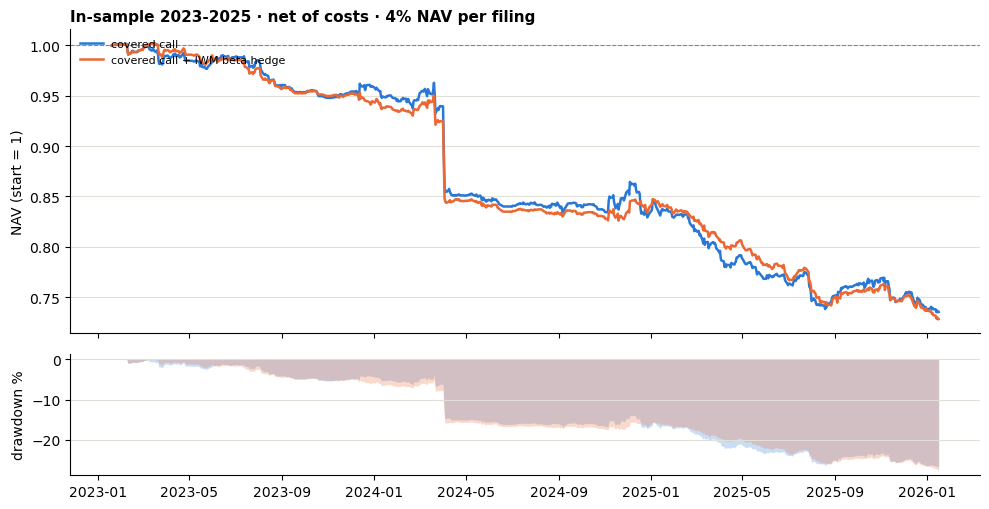

In [108]:
bt_is = portfolio_backtest(rules, structs)
bt_is_h = portfolio_backtest(rules, structs, hedge=True)
perf = [perf_metrics(bt_is, rules, "in-sample"), perf_metrics(bt_is_h, rules, "in-sample, beta-hedged")]
plot_equity({"covered call": bt_is["nav"], "covered call + IWM beta hedge": bt_is_h["nav"]},
            f"In-sample {STUDY_START[:4]}-{STUDY_END[:4]} · net of costs · {W_FILING:.0%} NAV per filing")

## 20 · Out-of-sample windows, run once with everything frozen (delay, rules, costs, caps)

  52,164 8-K disclosures, 2026-01-01..2026-08-31 (one page set; item_codes is not a server filter)
311 convertible note offering disclosures after keyword filter
dropped 9 filing rows with no usable ticker symbol
concurrent-repurchase screen: 254 -> 250 events (47 merely mention a repurchase, kept as a flag)
After filters: 250 events (5 with capped call, 245 without)
acceptance times: 250/250 found in 0s; 150 events moved to a later first tradable close
OOS 2026 (delay 0): 250 events -> 228 structures on 108 filings; 340 drops; 7s
screening 82 priced filings (of the full funnel)
screened 82 priced filings


C:\Users\yash2\AppData\Local\Temp\ipykernel_28236\606240796.py:98: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  start = (ref - pd.Timedelta(days=130)).strftime("%Y-%m-%d")
C:\Users\yash2\AppData\Local\Temp\ipykernel_28236\606240796.py:99: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  end = (max(expiries) + pd.Timedelta(days=10)).strftime("%Y-%m-%d")


placebo OOS 2026 (delay 0): 600 events -> 523 structures on 243 filings; 873 drops; 18s


,h=1,h=2,h=3,h=5,h=10,h=21,expiry
OOS 2026 covered call,"-2.31%* [-3.61, -1.11]","-2.15%* [-3.40, -1.05]","-1.88%* [-3.26, -0.62]","-1.61% [-3.55, +0.03]","-1.36% [-3.83, +0.99]","-1.67% [-5.04, +1.45]","+0.70% [-1.80, +3.17]"
OOS 2026 covered call: filings,82,82,82,82,79,63,81
OOS 2026 beta-hedged,"-2.41%* [-3.72, -1.24]","-2.26%* [-3.52, -1.14]","-2.06%* [-3.42, -0.87]","-1.81%* [-3.65, -0.33]","-1.66% [-4.12, +0.84]","-1.88% [-5.41, +1.68]","+0.05% [-2.31, +2.68]"
OOS 2026 beta-hedged: filings,82,82,82,82,79,63,81
OOS 2026 placebo,"-3.22%* [-4.76, -1.91]","-3.26%* [-5.07, -1.78]","-3.36%* [-5.33, -1.79]","-2.76%* [-4.54, -1.28]","-3.03%* [-5.28, -1.13]","-2.16% [-4.54, +0.15]","-0.00% [-1.67, +1.49]"
OOS 2026 placebo: filings,243,243,243,238,230,193,241
OOS 2026 event - placebo,"+0.92% [-1.00, +2.96]","+1.10% [-0.97, +3.29]","+1.48% [-0.68, +3.92]","+1.15% [-1.56, +3.62]","+1.67% [-1.42, +4.88]","+0.49% [-3.67, +4.29]","+0.71% [-2.32, +3.70]"


OOS 2026 rule exit: -1.55% net per filing [-3.36%, +0.03%], n = 82 filings


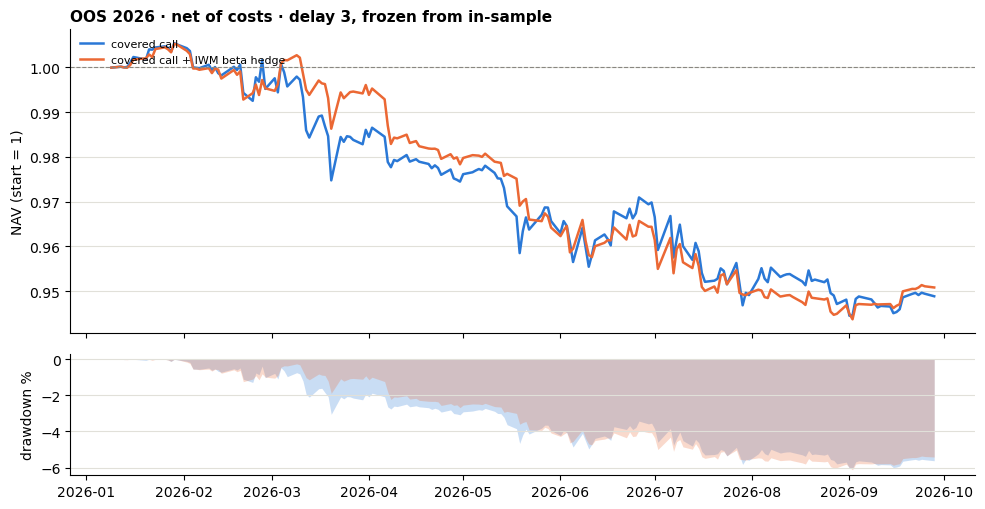

  118,885 8-K disclosures, 2021-07-01..2022-12-31 (one page set; item_codes is not a server filter)
534 convertible note offering disclosures after keyword filter
dropped 61 filing rows with no usable ticker symbol
concurrent-repurchase screen: 422 -> 414 events (49 merely mention a repurchase, kept as a flag)
After filters: 414 events (5 with capped call, 409 without)
acceptance times: 414/414 found in 0s; 239 events moved to a later first tradable close


C:\Users\yash2\AppData\Local\Temp\ipykernel_28236\606240796.py:122: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  leg = Leg(tk, "call", k, option_bars(tk, ref - pd.Timedelta(days=10), expiry))
C:\Users\yash2\AppData\Local\Temp\ipykernel_28236\2677735232.py:17: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  "expiration_date.gte": (as_of + pd.Timedelta(days=dte_lo)).strftime("%Y-%m-%d"),
C:\Users\yash2\AppData\Local\Temp\ipykernel_28236\2677735232.py:18: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit

Stress 2021-22 (delay 0): 414 events -> 395 structures on 206 filings; 476 drops; 12s
screening 151 priced filings (of the full funnel)
screened 151 priced filings


C:\Users\yash2\AppData\Local\Temp\ipykernel_28236\606240796.py:98: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  start = (ref - pd.Timedelta(days=130)).strftime("%Y-%m-%d")
C:\Users\yash2\AppData\Local\Temp\ipykernel_28236\2677735232.py:17: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  "expiration_date.gte": (as_of + pd.Timedelta(days=dte_lo)).strftime("%Y-%m-%d"),
C:\Users\yash2\AppData\Local\Temp\ipykernel_28236\2677735232.py:18: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  "expirat

placebo Stress 2021-22 (delay 0): 600 events -> 481 structures on 230 filings; 868 drops; 18s


,h=1,h=2,h=3,h=5,h=10,h=21,expiry
Stress 2021-22 covered call,"-3.16%* [-5.16, -1.74]","-3.05%* [-5.28, -1.45]","-2.59%* [-4.86, -0.99]","-2.68%* [-5.12, -0.88]","-2.75%* [-4.90, -0.98]","-3.08%* [-5.88, -0.30]","-2.46% [-5.14, +0.43]"
Stress 2021-22 covered call: filings,151,151,151,149,140,93,148
Stress 2021-22 beta-hedged,"-3.00%* [-4.96, -1.64]","-2.92%* [-5.12, -1.40]","-2.49%* [-4.65, -1.01]","-2.72%* [-5.09, -1.07]","-2.39%* [-4.15, -0.92]","-2.21% [-4.45, +0.07]","-0.72% [-2.89, +1.59]"
Stress 2021-22 beta-hedged: filings,151,151,151,149,140,93,148
Stress 2021-22 placebo,"-1.74%* [-2.31, -1.19]","-2.27%* [-3.02, -1.57]","-2.36%* [-3.22, -1.50]","-2.19%* [-3.04, -1.41]","-1.49%* [-2.63, -0.47]","-2.37%* [-4.14, -0.73]","-1.47% [-3.31, +0.33]"
Stress 2021-22 placebo: filings,230,230,230,227,221,179,230
Stress 2021-22 event - placebo,"-1.43% [-3.57, +0.11]","-0.78% [-3.11, +1.02]","-0.23% [-2.61, +1.64]","-0.49% [-3.03, +1.46]","-1.26% [-3.49, +0.87]","-0.71% [-4.07, +2.67]","-0.99% [-4.19, +2.27]"


Stress 2021-22 rule exit: -3.09% net per filing [-5.38%, -1.29%], n = 151 filings


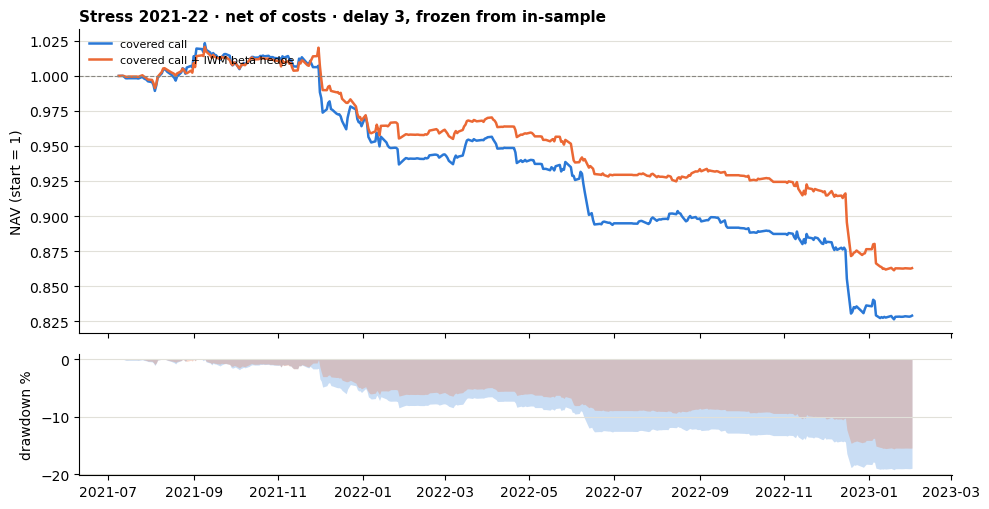

In [109]:
def run_window(start: str, end: str, label: str, n_placebo: int = N_PLACEBO_OOS):
    ev = build_events_v2(start, end)
    if ev.empty:
        print(f"{label}: no events")
        return None
    s0, dr = price_events_v2(ev, 0, label)
    s = shift_entry(s0, ENTRY_DELAY)
    attach_capped_flags(s, ev)
    fx, ru = evaluate_v2(s, keep_paths=True)
    pe = sample_placebo_events(ev, n_placebo, start, end, seed=11)
    ps, _ = price_events_v2(pe, 0, f"placebo {label}")
    pfx, _ = evaluate_v2(ps)
    display(pd.concat([fmt_ci(board_v2(fx), name=f"{label} covered call"),
                       fmt_ci(board_v2(fx, "hedged"), name=f"{label} beta-hedged"),
                       fmt_ci(board_v2(pfx), name=f"{label} placebo"),
                       fmt_ci(diff_board(fx, pfx), value="difference", name=f"{label} event - placebo")]))
    out = {"events": ev, "structs": s, "fixed": fx, "rules": ru, "placebo_fixed": pfx}
    if not ru.empty:
        f = filing_level(ru, "net")
        lo, hi = cluster_ci(f.net, f.ticker)
        print(f"{label} rule exit: {f.net.mean():+.2%} net per filing [{lo:+.2%}, {hi:+.2%}], n = {len(f)} filings")
        out["bt"] = portfolio_backtest(ru, s)
        out["bt_h"] = portfolio_backtest(ru, s, hedge=True)
        perf.append(perf_metrics(out["bt"], ru, label))
        perf.append(perf_metrics(out["bt_h"], ru, f"{label}, beta-hedged"))
        plot_equity({"covered call": out["bt"]["nav"], "covered call + IWM beta hedge": out["bt_h"]["nav"]},
                    f"{label} · net of costs · delay {ENTRY_DELAY}, frozen from in-sample")
    return out


oos = run_window(OOS_START, OOS_END, "OOS 2026")
stress = run_window(STRESS_START, STRESS_END, "Stress 2021-22") if RUN_STRESS_WINDOW else None

{'variant': 'in-sample', 'filings': 102, 'gross': np.float64(0.03632092637008421), 'cost': np.float64(0.005705949506199184), 'net / filing': np.float64(0.026300172059193137), 'ci_lo': np.float64(0.01189827845803556), 'ci_hi': np.float64(0.04050656033344799)}


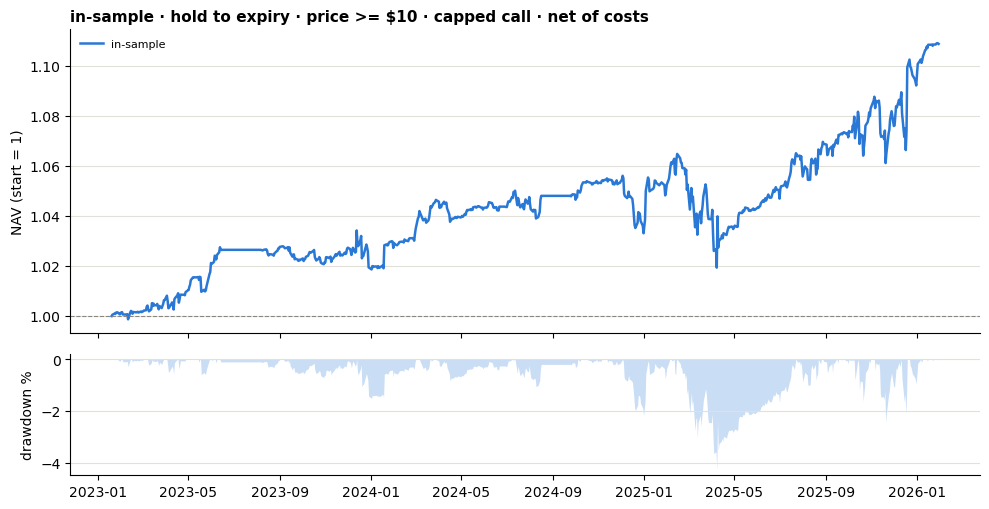

{'variant': 'OOS 2026', 'filings': 32, 'gross': np.float64(0.04104429407497935), 'cost': np.float64(0.005531940333023111), 'net / filing': np.float64(0.015948677402558287), 'ci_lo': np.float64(-0.020084873000390354), 'ci_hi': np.float64(0.04879589406812909)}


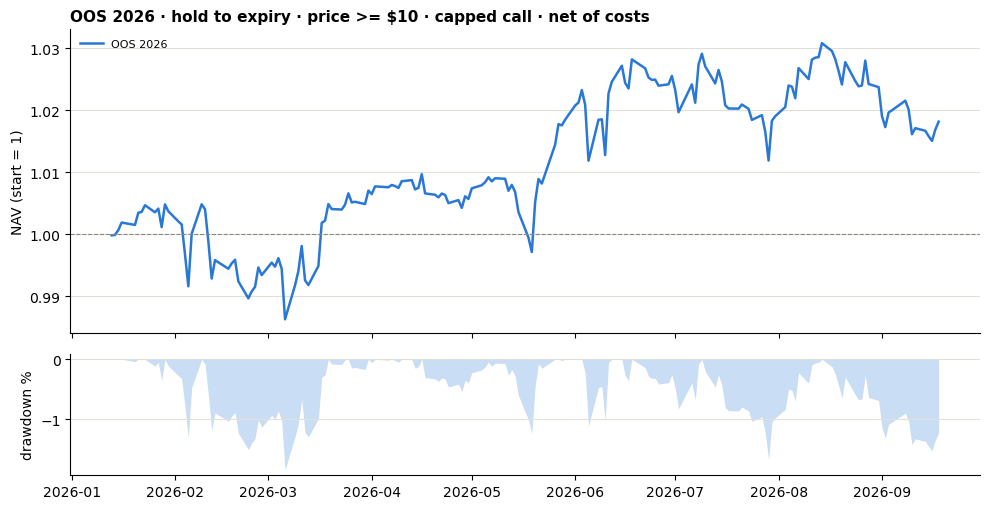

{'variant': 'Stress 2021-22', 'filings': 54, 'gross': np.float64(-0.02349266327625247), 'cost': np.float64(0.004946373950175995), 'net / filing': np.float64(-0.043628632155546306), 'ci_lo': np.float64(-0.08767800423922206), 'ci_hi': np.float64(-0.0011411605603683886)}


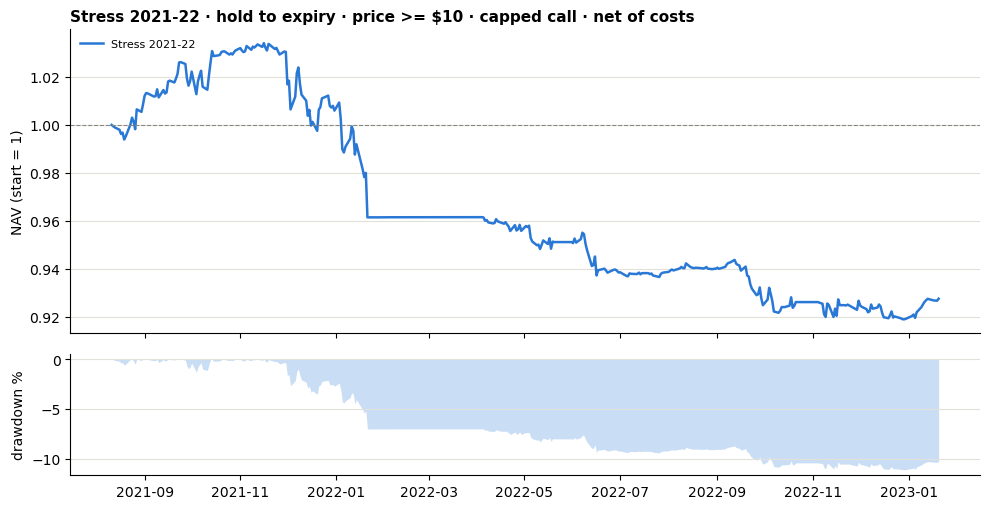

window,in-sample,OOS 2026,Stress 2021-22
annualized return (CAGR),+3.48%,+2.68%,-5.09%
annualized volatility,4.02%,4.56%,4.56%
"Sharpe (rf = 0, daily)",0.87,0.61,-1.12
max drawdown,-4.27%,-1.85%,-11.12%
"turnover (one-way, x NAV / yr)",1.3,1.8,1.4
avg gross exposure,10%,15%,11%
return per unit exposure (ann.),+34.08%,+18.58%,-47.21%
trades / filings,253 / 102,65 / 32,99 / 54
trade win rate (net),71%,72%,55%
filings skipped by caps,2,0,4


In [102]:
CHOSEN_FILTER = "capped call"     # decided from Cell C, in-sample only

WINDOWS = [("in-sample", structs)]
if oos and oos.get("structs"):
    WINDOWS.append(("OOS 2026", oos["structs"]))
if stress and stress.get("structs"):
    WINDOWS.append(("Stress 2021-22", stress["structs"]))

summary = []
for label, st_list in WINDOWS:
    s, ru = eval_base(st_list, keep_paths=True)
    ru = ru[FILTERS[CHOSEN_FILTER](ru)]
    if ru.empty:
        print(label, ": no trades"); continue
    print(summarize(ru, label))
    bt = portfolio_backtest(ru, s)
    summary.append(perf_metrics(bt, ru, label))
    plot_equity({label: bt["nav"]},
                f"{label} · hold to expiry · price >= ${MIN_PRICE} · {CHOSEN_FILTER} · net of costs")
display(pd.DataFrame(summary).set_index("window").T)


{'variant': 'in-sample', 'filings': 229, 'gross': np.float64(0.02845493318383595), 'cost': np.float64(0.005478246924207739), 'net / filing': np.float64(0.02097657466995547), 'ci_lo': np.float64(0.011336364816748086), 'ci_hi': np.float64(0.03085125426313606)}


,in-sample
window,in-sample
annualized return (CAGR),+6.12%
annualized volatility,7.35%
"Sharpe (rf = 0, daily)",0.85
max drawdown,-5.63%
"turnover (one-way, x NAV / yr)",2.9
avg gross exposure,23%
return per unit exposure (ann.),+26.67%
trades / filings,534 / 229
trade win rate (net),68%


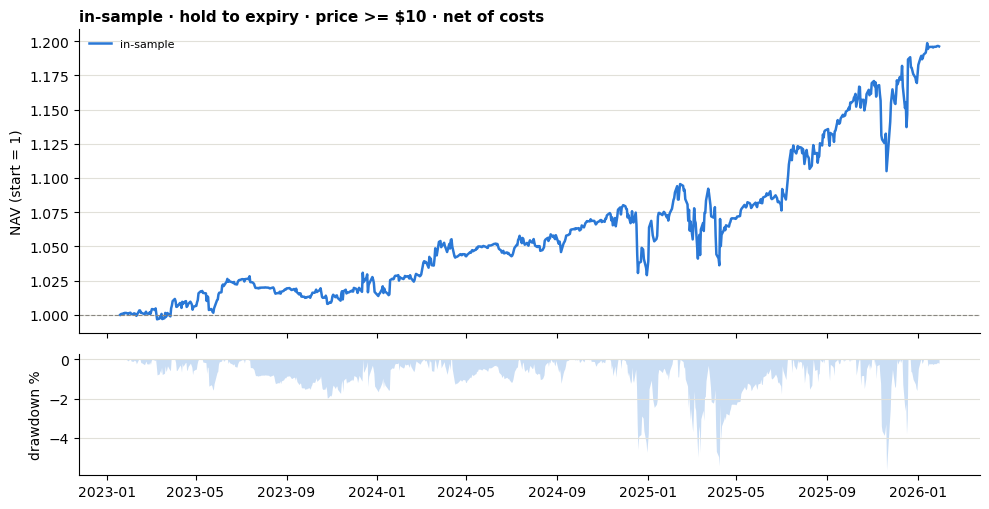

{'variant': 'OOS 2026', 'filings': 54, 'gross': np.float64(0.028975265982123), 'cost': np.float64(0.005065068165408734), 'net / filing': np.float64(0.011925065749845757), 'ci_lo': np.float64(-0.014615056850180759), 'ci_hi': np.float64(0.03819831319133022)}


,OOS 2026
window,OOS 2026
annualized return (CAGR),+2.75%
annualized volatility,6.45%
"Sharpe (rf = 0, daily)",0.45
max drawdown,-2.94%
"turnover (one-way, x NAV / yr)",2.9
avg gross exposure,23%
return per unit exposure (ann.),+12.66%
trades / filings,102 / 54
trade win rate (net),67%


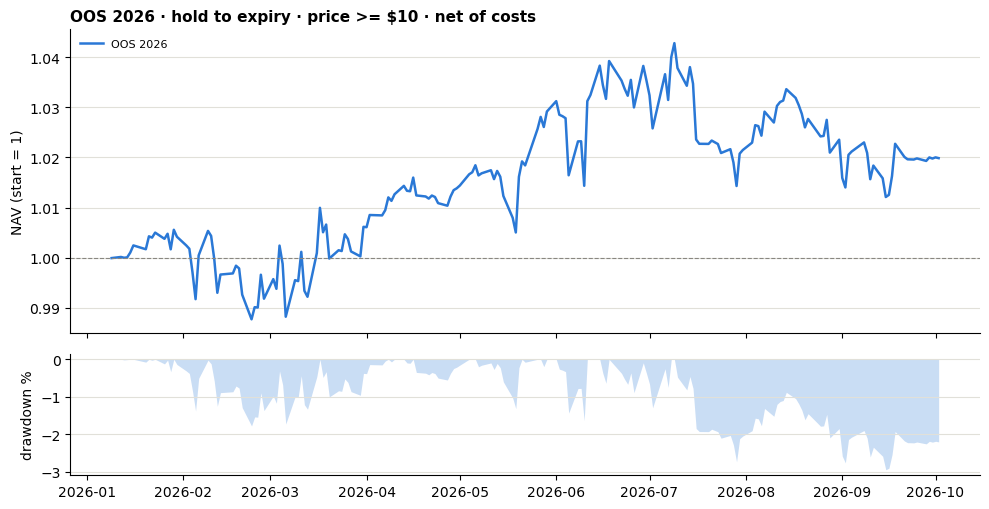

In [111]:
CHOSEN_POLICY = "hold to expiry"   # set from Cell A, in-sample only
MIN_PRICE = 10                     # set from Cell A, in-sample only


def run_frozen(st_list, label):
    s = [x for x in st_list if x.S_e >= MIN_PRICE]
    fx, ru = evaluate_v2(s, keep_paths=True, **POLICIES[CHOSEN_POLICY])
    print(summarize(ru, label))
    bt = portfolio_backtest(ru, s)
    display(perf_metrics(bt, ru, label).to_frame())
    plot_equity({label: bt["nav"]}, f"{label} · {CHOSEN_POLICY} · price >= ${MIN_PRICE} · net of costs")
    return fx, ru


fx_is, ru_is = run_frozen(structs, "in-sample")
fx_oos, ru_oos = run_frozen(oos["structs"], "OOS 2026") if oos and oos.get("structs") else (None, None)


## 21 · Performance summary — every number net of costs; in-sample and out-of-sample reported separately

In [110]:
display(pd.DataFrame(perf).set_index("window").T)

window,in-sample,"in-sample, beta-hedged",OOS 2026,"OOS 2026, beta-hedged",Stress 2021-22,"Stress 2021-22, beta-hedged"
annualized return (CAGR),-9.81%,-10.10%,-7.12%,-6.85%,-11.30%,-9.00%
annualized volatility,5.95%,5.22%,4.81%,3.83%,5.53%,4.66%
"Sharpe (rf = 0, daily)",-1.70,-2.01,-1.51,-1.83,-2.14,-1.99
max drawdown,-26.63%,-27.37%,-6.05%,-6.12%,-19.22%,-15.59%
"turnover (one-way, x NAV / yr)",4.7,4.7,4.6,4.6,3.8,3.8
avg gross exposure,14%,14%,15%,15%,11%,11%
return per unit exposure (ann.),-71.93%,-74.54%,-48.66%,-47.02%,-109.33%,-86.04%
trades / filings,898 / 364,898 / 364,166 / 82,166 / 82,288 / 151,288 / 151
trade win rate (net),50%,50%,51%,51%,38%,38%
filings skipped by caps,2,2,0,0,0,1
